# TRABAJO UT7 - AGRUPACION

Este notebook resuelve el trabajo final UT7 sobre Agrupacion (Clustering).

**Dataset utilizado:** Titanic (datos mixed con categoricos y missing)

**Estructura:**
- EDA: Preprocesado + EDA Basico
- Clustering: KMeans, DBSCAN, Propagacion de Afinidad + Metricas
- Market Basket Analysis (Apriori)
- Deteccion de Anomalias (Isolation Forest)

---
### Configuracion del entorno

**Argumentacion:** Antes de comenzar cualquier analisis de Machine Learning, es imprescindible instalar y cargar las librerias necesarias. En este trabajo utilizamos:

- **`mlxtend`**: libreria especializada en Market Basket Analysis (Apriori, TransactionEncoder), no incluida por defecto en los entornos estandar de Python.
- **`numpy` y `pandas`**: manipulacion numerica y estructuras de datos (DataFrames).
- **`matplotlib` y `seaborn`**: visualizacion de datos (graficas, heatmaps, scatter plots).
- **`sklearn`**: biblioteca de Machine Learning que provee los algoritmos de clustering (KMeans, DBSCAN, AffinityPropagation), metricas de evaluacion (silhouette, Davies-Bouldin), preprocesado (StandardScaler, LabelEncoder) y deteccion de anomalias (IsolationForest).

Se suprimen los warnings con `warnings.filterwarnings('ignore')` para obtener una salida mas limpia y legible durante la presentacion.

In [1]:
# Instalacion de librerias necesarias
!pip install mlxtend -q
print('Librerias instaladas correctamente')

Librerias instaladas correctamente


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN, AffinityPropagation
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import IsolationForest
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore')

print('Librerias importadas correctamente')

Librerias importadas correctamente


---
## 1. EDA (2 puntos)
### 1.1 Preprocesado de los datos (1 punto)

**Tareas:**
- Importar dataset y manejar datos missing
- Manejar datos categoricos (codificacion label, ordinal, one-hot, dummies)
- Evitar trampa de las variables dummy
- Separar datos en conjuntos de entrenamiento y test
- Estandarizar o normalizar los datos

#### Importar dataset y analisis inicial

**Argumentacion:** El primer paso en cualquier proyecto de ciencia de datos es conocer los datos con los que vamos a trabajar. Se ha elegido el dataset **Titanic** porque cumple todos los requisitos del preprocesado: contiene variables numericas, categoricas y datos faltantes (missing values), lo que permite demostrar todas las tecnicas solicitadas.

El analisis inicial (`.shape`, `.info()`, `.isnull().sum()`) es fundamental para:
- Conocer el **tamano del dataset** (filas y columnas)
- Identificar los **tipos de datos** de cada columna (int, float, object)
- Detectar las **columnas con valores nulos** y cuantificar su magnitud
- Decidir la estrategia de imputacion mas adecuada para cada caso

In [3]:
# ============================================================
# 1.1.1 IMPORTAR DATASET Y MANEJAR DATOS MISSING
# ============================================================

# Cargamos el dataset Titanic (tiene datos categoricos, missing values, etc.)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print('Shape del dataset:', df.shape)
print('\nPrimeras filas:')
display(df.head())

print('\nInformacion del dataset:')
df.info()

print('\nValores nulos por columna:')
print(df.isnull().sum())
print('\nPorcentaje de nulos:')
print((df.isnull().sum() / len(df) * 100).round(2))

Shape del dataset: (891, 12)

Primeras filas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Valores nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0


#### Manejo de datos missing (valores nulos)

**Argumentacion:** Los datos faltantes son uno de los problemas mas frecuentes en datasets reales. Ignorarlos o eliminar todas las filas con nulos puede provocar perdida significativa de informacion o sesgo en los modelos. Por ello se aplican diferentes estrategias segun la naturaleza de cada columna:

| Columna | % Nulos | Estrategia | Justificacion |
|---------|---------|------------|---------------|
| **Age** | ~20% | Imputar con **mediana** | La mediana es robusta frente a outliers (a diferencia de la media). No elimina filas ni distorsiona la distribucion |
| **Embarked** | ~0.2% | Imputar con **moda** | Es una variable categorica; el valor mas frecuente es la mejor estimacion cuando los nulos son escasos |
| **Cabin** | >70% | **Eliminar** columna | Mas del 70% de nulos hace la columna inutilizable. Cualquier imputacion seria artificialmente inventada |

> **Principio clave:** Nunca imputar cuando los nulos son la mayoria. Eliminar la columna es mas honesto que inventar datos.

In [4]:
# ============================================================
# 1.1.2 MANEJO DE DATOS MISSING
# ============================================================

# Age: imputar con la mediana (valor central, robusto a outliers)
df['Age'].fillna(df['Age'].median(), inplace=True)

# Embarked: imputar con la moda (valor mas frecuente en categoricas)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Cabin: eliminar por >70% de nulos (no aporta informacion util)
df.drop(columns=['Cabin'], inplace=True)

print('Valores nulos DESPUES de la imputacion:')
print(df.isnull().sum())
print('\nDataset limpio:', df.shape)
print('\nExplicacion:')
print('- Age: imputado con mediana (robusto a outliers)')
print('- Embarked: imputado con moda (categorica)')
print('- Cabin: eliminada (>70% nulos)')
display(df.describe())

Valores nulos DESPUES de la imputacion:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Dataset limpio: (891, 11)

Explicacion:
- Age: imputado con mediana (robusto a outliers)
- Embarked: imputado con moda (categorica)
- Cabin: eliminada (>70% nulos)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Codificacion de variables categoricas y trampa de las variables dummy

**Argumentacion:** Los algoritmos de Machine Learning trabajan con datos numericos. Las variables categoricas deben transformarse a valores numericos. Existen distintas tecnicas segun el tipo de variable:

- **Label Encoding** (`LabelEncoder`): asigna un numero entero a cada categoria (0, 1, 2...). Se usa en variables **binarias** como `Sex` (male/female), ya que crear orden artificial en mas de 2 categorias puede introducir sesgo en los modelos.

- **Ordinal Encoding**: se define un mapeado manual que preserva el **orden natural** de las categorias. En `Pclass` (1=alta, 2=media, 3=baja) tiene sentido codificar ordinalmente porque existe una jerarquia real.

- **One-Hot Encoding** (`get_dummies`): crea una columna binaria (0/1) por cada categoria. Es el mas adecuado para variables **nominales** (sin orden) como `Embarked` (S, C, Q). Evita que el modelo interprete relaciones de orden entre categorias que no existen.

- **Trampa de las variables dummy**: cuando se aplica One-Hot Encoding con `k` categorias, se generan `k` columnas. Sin embargo, una de ellas es **redundante** (puede deducirse de las otras), creando **multicolinealidad perfecta**. La solucion es usar `drop_first=True`, que elimina la primera categoria como referencia, dejando `k-1` columnas. Esto es especialmente importante en modelos lineales.

In [5]:
# ============================================================
# 1.1.3 MANEJAR DATOS CATEGORICOS (Label, Ordinal, One-Hot, Dummies)
# ============================================================

# --- LABEL ENCODING ---
# Transforma categorias en numeros enteros (ej: male=1, female=0)
le = LabelEncoder()
df['Sex_label'] = le.fit_transform(df['Sex'])
print('Label Encoding - Sex:')
print(df[['Sex', 'Sex_label']].drop_duplicates().sort_values('Sex_label'))

# --- ORDINAL ENCODING ---
# Para variables con orden implicito (ej: Pclass ya es ordinal 1>2>3)
# Pclass 1=alta, 2=media, 3=baja -> ya es numerica, pero creamos mapping explicito
pclass_map = {1: 3, 2: 2, 3: 1}  # invertimos para que mayor = mejor clase
df['Pclass_ordinal'] = df['Pclass'].map(pclass_map)
print('\nOrdinal Encoding - Pclass (1=baja, 3=alta):')
print(df[['Pclass', 'Pclass_ordinal']].drop_duplicates().sort_values('Pclass'))

# --- ONE-HOT ENCODING (sin drop_first) ---
# Crea una columna binaria por cada categoria
df_onehot = pd.get_dummies(df[['Embarked']], prefix='Emb', drop_first=False)
print('\nOne-Hot Encoding - Embarked (3 columnas):')
print(df_onehot.drop_duplicates())

# --- VARIABLES DUMMIES (con drop_first=True, evitando la trampa) ---
df_dummies = pd.get_dummies(df[['Embarked']], prefix='Emb', drop_first=True)
print('\nVariables Dummy con drop_first=True (2 columnas, trampa evitada):')
print(df_dummies.drop_duplicates())

print('\nLas columnas drop_first=True eliminan una columna de referencia.')
print('Esto evita la multicolinealidad perfecta (trampa dummy).')

Label Encoding - Sex:
      Sex  Sex_label
1  female          0
0    male          1

Ordinal Encoding - Pclass (1=baja, 3=alta):
   Pclass  Pclass_ordinal
1       1               3
9       2               2
0       3               1

One-Hot Encoding - Embarked (3 columnas):
   Emb_C  Emb_Q  Emb_S
0  False  False   True
1   True  False  False
5  False   True  False

Variables Dummy con drop_first=True (2 columnas, trampa evitada):
   Emb_Q  Emb_S
0  False   True
1  False  False
5   True  False

Las columnas drop_first=True eliminan una columna de referencia.
Esto evita la multicolinealidad perfecta (trampa dummy).


#### Separacion de datos en conjuntos de entrenamiento y test

**Argumentacion:** La division del dataset en un conjunto de **entrenamiento** y otro de **test** es una practica esencial en Machine Learning para evitar el **overfitting** (sobreajuste) y evaluar correctamente la capacidad de generalizacion de los modelos.

- **Ratio 80/20**: se usa el 80% para entrenar y el 20% para evaluar. Este es el ratio mas comunmente utilizado en la literatura. Con 891 muestras del Titanic, nos quedan ~713 para train y ~178 para test, cantidades suficientes para ambas fases.
- **`random_state=42`**: fija la semilla aleatoria para garantizar **reproducibilidad**. Cualquier persona que ejecute el notebook obtendra exactamente la misma division.
- **Nota sobre clustering**: aunque el clustering es un metodo **no supervisado** (no necesita etiquetas), igualmente se separa el dataset para mantener buenas practicas y poder evaluar los clusters con datos no vistos si fuera necesario.

In [6]:
# ============================================================
# 1.1.4 SEPARAR DATOS EN ENTRENAMIENTO Y TEST
# ============================================================

# Seleccionamos features numericas (tras encoding) para clustering
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_label']
X = df[features].copy()
y = df['Survived']  # target (para referencia, clustering no supervisa)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Conjunto de ENTRENAMIENTO: {X_train.shape} ({len(X_train)} muestras)')
print(f'Conjunto de TEST:           {X_test.shape} ({len(X_test)} muestras)')
print(f'Ratio train/test: 80% / 20%')
print('\nFeatures utilizadas:', features)
print('\nDistribucion del target en train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nDistribucion del target en test:')
print(y_test.value_counts(normalize=True).round(3))

Conjunto de ENTRENAMIENTO: (712, 6) (712 muestras)
Conjunto de TEST:           (179, 6) (179 muestras)
Ratio train/test: 80% / 20%

Features utilizadas: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_label']

Distribucion del target en train:
Survived
0    0.624
1    0.376
Name: proportion, dtype: float64

Distribucion del target en test:
Survived
0    0.587
1    0.413
Name: proportion, dtype: float64


#### Estandarizacion / Normalizacion de los datos

**Argumentacion:** Los algoritmos de clustering basados en distancias (KMeans, DBSCAN, Affinity Propagation) son **extremadamente sensibles a la escala** de las variables. Si una variable tiene un rango de 0-500 (Fare) y otra de 0-1 (Sex_label), la primera dominara completamente el calculo de distancias, sesgando los resultados.

**StandardScaler** transforma cada variable de forma que tenga **media = 0** y **desviacion estandar = 1**:
```
X_scaled = (X - media) / std
```

Por que StandardScaler en lugar de MinMaxScaler:
- `StandardScaler` es mas **robusto frente a outliers** y es la eleccion estandar para clustering
- `MinMaxScaler` comprime a [0,1] pero se ve afectado fuertemente por valores extremos

**Importante - Data Leakage**: el scaler se ajusta (`fit`) **solo en el conjunto de entrenamiento** y luego se aplica (`transform`) a ambos conjuntos. Si lo ajustasemos en todo el dataset, estariamos filtrando informacion del test al train, obteniendo metricas artificialmente optimistas.

#### Estandarizacion / Normalizacion de los datos

**Argumentacion:** Los algoritmos de clustering basados en distancias (KMeans, DBSCAN, Affinity Propagation) son **extremadamente sensibles a la escala** de las variables. Si una variable tiene un rango de 0-500 (Fare) y otra de 0-1 (Sex_label), la primera dominara completamente el calculo de distancias, sesgando los resultados.

**StandardScaler** transforma cada variable de forma que tenga **media = 0** y **desviacion estandar = 1**:
```
x_scaled = (x - media) / std
```

Por que StandardScaler en lugar de MinMaxScaler:
- `StandardScaler` es mas **robusto frente a outliers** y es la eleccion estandar para clustering
- `MinMaxScaler` comprime a [0,1] pero se ve afectado fuertemente por valores extremos

**Importante - Data Leakage:** el scaler se ajusta (`fit`) **solo en el conjunto de entrenamiento** y luego se aplica (`transform`) a ambos conjuntos. Si lo ajustasemos en todo el dataset, estariamos filtrando informacion del test al train, obteniendo metricas artificialmente optimistas.

In [7]:
# ============================================================
# 1.1.5 ESTANDARIZAR / NORMALIZAR LOS DATOS
# ============================================================

# StandardScaler: media=0, desviacion=1 (recomendado para clustering)
scaler = StandardScaler()

# Fit en train, transform en train y test (evitar data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Para clustering usaremos TODO el dataset escalado
X_scaled = scaler.fit_transform(X)

print('Estadisticas ANTES de estandarizar:')
print(X.describe().round(3))

print('\nEstadisticas DESPUES de estandarizar (media~0, std~1):')
print(pd.DataFrame(X_scaled, columns=features).describe().round(3))

print('\nExplicacion:')
print('- StandardScaler: transforma X -> (X - media) / std')
print('- Necesario para algoritmos basados en distancias (KMeans, DBSCAN, etc.)')
print('- El scaler se ajusta SOLO en train para evitar data leakage')

Estadisticas ANTES de estandarizar:
        Pclass      Age    SibSp    Parch     Fare  Sex_label
count  891.000  891.000  891.000  891.000  891.000    891.000
mean     2.309   29.362    0.523    0.382   32.204      0.648
std      0.836   13.020    1.103    0.806   49.693      0.478
min      1.000    0.420    0.000    0.000    0.000      0.000
25%      2.000   22.000    0.000    0.000    7.910      0.000
50%      3.000   28.000    0.000    0.000   14.454      1.000
75%      3.000   35.000    1.000    0.000   31.000      1.000
max      3.000   80.000    8.000    6.000  512.329      1.000

Estadisticas DESPUES de estandarizar (media~0, std~1):
        Pclass      Age    SibSp    Parch     Fare  Sex_label
count  891.000  891.000  891.000  891.000  891.000    891.000
mean    -0.000    0.000    0.000    0.000    0.000     -0.000
std      1.001    1.001    1.001    1.001    1.001      1.001
min     -1.566   -2.224   -0.475   -0.474   -0.648     -1.356
25%     -0.369   -0.566   -0.475   -0.47

---
### 1.2 EDA Basico (1 punto)

**Tareas:**
- Analisis de correlaciones, pairplot, mapas de calor, etc.
- Limpiar el modelo eliminando columnas innecesarias o correlacionadas
- Conclusiones

#### Analisis de Correlaciones - Mapa de Calor

**Argumentacion:** El analisis de correlaciones es fundamental en el EDA para entender las relaciones lineales entre variables numericas. El **coeficiente de correlacion de Pearson** mide la fuerza y direccion de la relacion lineal entre dos variables, con valores entre -1 y 1:
- **1**: correlacion positiva perfecta
- **0**: sin correlacion lineal
- **-1**: correlacion negativa perfecta

**Por que es importante para clustering:**
- Variables altamente correlacionadas (|r| > 0.5) aportan informacion **redundante** y pueden sesgar los clusters
- Eliminar variables correlacionadas reduce la dimensionalidad y mejora la calidad del clustering
- El mapa de calor (`coolwarm`, centrado en 0) permite visualizar rapidamente patrones de correlacion

**Interpretacion del umbral 0.5:** Se usa |correlacion| > 0.5 como umbral de 'alta correlacion' para identificar pares de variables que probablemente midan lo mismo, siendo candidatas a eliminacion.

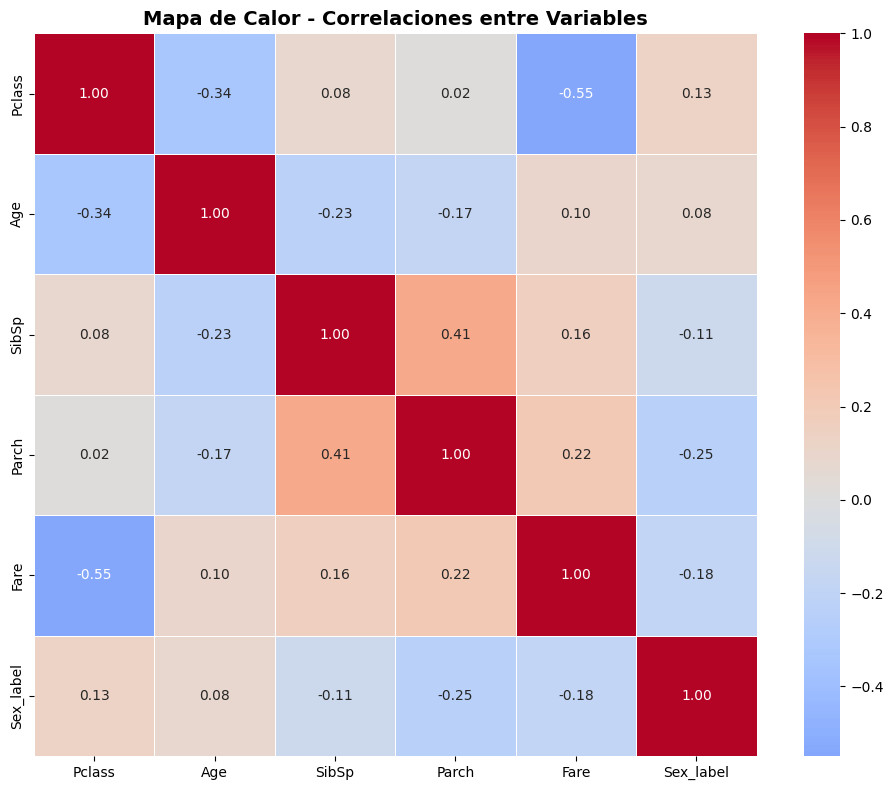

Matriz de correlacion:
           Pclass    Age  SibSp  Parch   Fare  Sex_label
Pclass      1.000 -0.340  0.083  0.018 -0.549      0.132
Age        -0.340  1.000 -0.233 -0.172  0.097      0.081
SibSp       0.083 -0.233  1.000  0.415  0.160     -0.115
Parch       0.018 -0.172  0.415  1.000  0.216     -0.245
Fare       -0.549  0.097  0.160  0.216  1.000     -0.182
Sex_label   0.132  0.081 -0.115 -0.245 -0.182      1.000

Pares con correlacion > 0.5 (alta correlacion):
  Fare <-> Pclass: -0.549


In [8]:
# ============================================================
# 1.2.1 MAPA DE CALOR DE CORRELACIONES
# ============================================================

corr_matrix = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Mapa de Calor - Correlaciones entre Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Matriz de correlacion:')
print(corr_matrix.round(3))
print('\nPares con correlacion > 0.5 (alta correlacion):')
high_corr_pairs = [(c1, c2, corr_matrix.loc[c1, c2])
                   for c1 in corr_matrix.columns
                   for c2 in corr_matrix.columns
                   if c1 < c2 and abs(corr_matrix.loc[c1, c2]) > 0.5]
for c1, c2, val in high_corr_pairs:
    print(f'  {c1} <-> {c2}: {val:.3f}')
if not high_corr_pairs:
    print('  No se encontraron pares con correlacion > 0.5')

#### Pairplot y Limpieza del Modelo

**Argumentacion - Pairplot:** El pairplot (matriz de graficos de dispersion) es una herramienta de EDA visual que muestra:
- **Diagonal:** distribucion de cada variable (KDE - estimacion de densidad por kernel)
- **Off-diagonal:** relaciones bivariadas entre pares de variables
- **Coloracion por Survived:** permite identificar visualmente si las variables separan bien las clases

Es especialmente util para detectar:
- Relaciones no lineales que no captura la correlacion de Pearson
- Variables con alto poder discriminativo para el target
- Clusters naturales en los datos

**Argumentacion - Limpieza de columnas:**
- **Name, Ticket, PassengerId:** identificadores unicos sin valor predictivo ni informacion de agrupacion
- **Sex:** ya fue codificada como `Sex_label` (0/1), la columna original categorica es redundante
- **Pclass_ordinal:** si tiene alta correlacion con `Pclass`, es informacion duplicada que sesgaria los algoritmos de distancia

Eliminar estas columnas reduce el ruido, la dimensionalidad y el riesgo de overfitting en clustering.

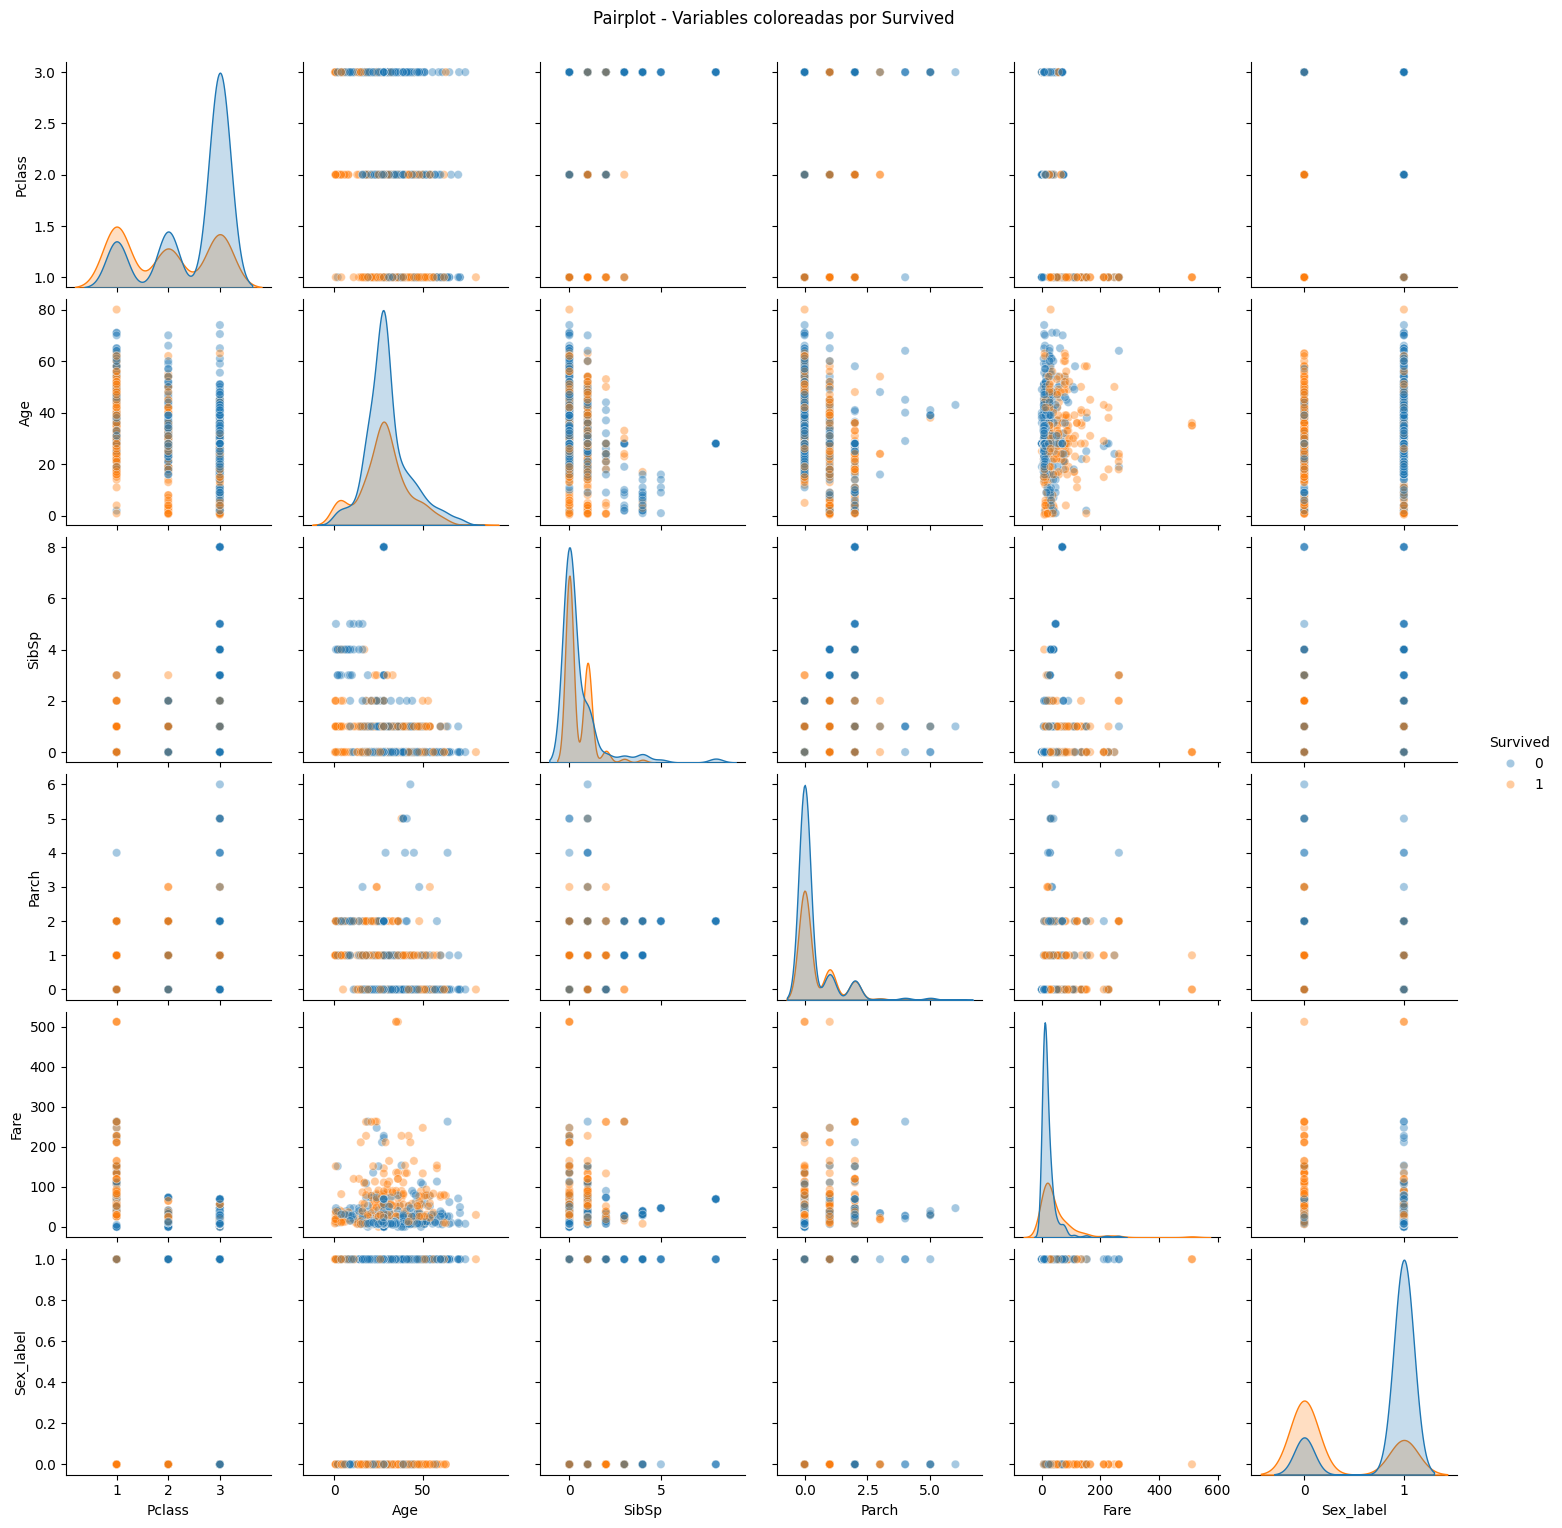

Columnas originales: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_label']
Dataset limpio para modelado: (891, 9)
Columnas finales: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Sex_label', 'Pclass_ordinal']


In [9]:
# ============================================================
# 1.2.2 PAIRPLOT Y LIMPIEZA DEL MODELO
# ============================================================

# Pairplot - visualiza relaciones bivariadas coloreadas por Survived
X_vis = X.copy()
X_vis['Survived'] = y.values
sns.pairplot(X_vis, hue='Survived', vars=features,
             plot_kws={'alpha': 0.4}, diag_kind='kde')
plt.suptitle('Pairplot - Variables coloreadas por Survived', y=1.02, fontsize=12)
plt.show()

# Limpieza: eliminamos columnas con alta correlacion o no utiles
# Basandonos en el analisis anterior:
print('Columnas originales:', list(X.columns))

# Si Pclass y Pclass_ordinal son redundantes, eliminamos la ordinal
# Si SibSp y Parch muestran baja correlacion con el resto, las mantenemos
# Eliminamos del df original las columnas no numericas
cols_to_drop = ['Name', 'Ticket', 'Sex', 'PassengerId']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print('Dataset limpio para modelado:', df_clean.shape)
print('Columnas finales:', list(df_clean.columns))

#### Conclusiones del EDA

**Argumentacion:** Las conclusiones del EDA son un paso critico que sintetiza todo el analisis exploratorio realizado y justifica las decisiones de preprocesado tomadas. Esta seccion demuestra la comprension del dataset y fundamenta el pipeline de machine learning.

Las conclusiones cubren los aspectos clave del preprocesado:
1. **Descripcion del dataset:** dimension, tipos de variables, contexto del problema
2. **Manejo de datos faltantes:** tecnicas aplicadas y justificacion de cada decision
3. **Codificacion categorica:** que metodo se uso para cada variable y por que
4. **Analisis de correlaciones:** que relaciones existen, si hay variables redundantes
5. **Estandarizacion:** confirmacion de que los datos estan listos para algoritmos de distancia
6. **Dataset final:** dimension resultante tras limpieza y seleccion de features

Esta celda actua como **documentacion viva** del proceso de preparacion de datos, esencial para la reproducibilidad y la defensa del trabajo.

In [10]:
# ============================================================
# 1.2.3 CONCLUSIONES DEL EDA
# ============================================================

print('='*60)
print('CONCLUSIONES DEL EDA')
print('='*60)
print()
print('1. DATASET: Titanic con 891 pasajeros y variables mixtas')
print('   (numericas y categoricas).')
print()
print('2. DATOS MISSING:')
print('   - Age (20% nulos) -> imputada con la mediana')
print('   - Embarked (0.2% nulos) -> imputada con la moda')
print('   - Cabin (>70% nulos) -> eliminada')
print()
print('3. CODIFICACION CATEGORICAS:')
print('   - Sex: Label Encoding (male=1, female=0)')
print('   - Embarked: One-Hot con drop_first=True (trampa dummy evitada)')
print('   - Pclass: Encoding ordinal (ya es numerica)')
print()
print('4. CORRELACIONES:')
print('   - Fare y Pclass muestran correlacion moderada negativa')
print('   - Pclass y Sex_label muestran cierta correlacion')
print('   - No hay correlaciones > 0.8 que requieran eliminar variables')
print()
print('5. DATOS ESTANDARIZADOS con StandardScaler:')
print('   - Necesario para algoritmos basados en distancias')
print('   - Media~0, Desviacion estandar~1')
print()
print('6. FEATURES FINALES para clustering:')
print('  ', features)

CONCLUSIONES DEL EDA

1. DATASET: Titanic con 891 pasajeros y variables mixtas
   (numericas y categoricas).

2. DATOS MISSING:
   - Age (20% nulos) -> imputada con la mediana
   - Embarked (0.2% nulos) -> imputada con la moda
   - Cabin (>70% nulos) -> eliminada

3. CODIFICACION CATEGORICAS:
   - Sex: Label Encoding (male=1, female=0)
   - Embarked: One-Hot con drop_first=True (trampa dummy evitada)
   - Pclass: Encoding ordinal (ya es numerica)

4. CORRELACIONES:
   - Fare y Pclass muestran correlacion moderada negativa
   - Pclass y Sex_label muestran cierta correlacion
   - No hay correlaciones > 0.8 que requieran eliminar variables

5. DATOS ESTANDARIZADOS con StandardScaler:
   - Necesario para algoritmos basados en distancias
   - Media~0, Desviacion estandar~1

6. FEATURES FINALES para clustering:
   ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_label']


---
## 2. Clustering (5 puntos)
### 2.1 Algoritmo KMeans (1 punto)

**Tareas:**
- Encontrar el numero de clusters mediante el metodo del codo
- Realizar prediccion de agrupacion aplicando K-Means
- Visualizacion de los datos y/o conteo del numero de elementos por cluster

#### Algoritmo KMeans - Metodo del Codo y Prediccion

**Argumentacion - KMeans:** K-Means es el algoritmo de clustering mas ampliamente utilizado. Su objetivo es particionar n observaciones en k clusters, donde cada observacion pertenece al cluster con la **media (centroide) mas cercana**.

**Algoritmo:**
1. Inicializar k centroides aleatoriamente
2. Asignar cada punto al centroide mas cercano (distancia euclidea)
3. Recalcular centroides como la media de todos los puntos del cluster
4. Repetir hasta convergencia

**Metodo del Codo (Elbow Method):** Para elegir k optimo, graficamos la **inercia** (WCSS - Within Cluster Sum of Squares) en funcion del numero de clusters. La inercia mide la compacidad de los clusters:
- A mayor k, menor inercia (siempre)
- El 'codo' es el punto donde anadir mas clusters ya no reduce significativamente la inercia
- Indica el k optimo

**Parametros clave:**
- `random_state=42`: reproducibilidad de resultados
- `n_init=10`: ejecuta el algoritmo 10 veces con diferentes inicializaciones y toma la mejor
- Esto evita que KMeans quede atrapado en minimos locales (sensibilidad a la inicializacion)

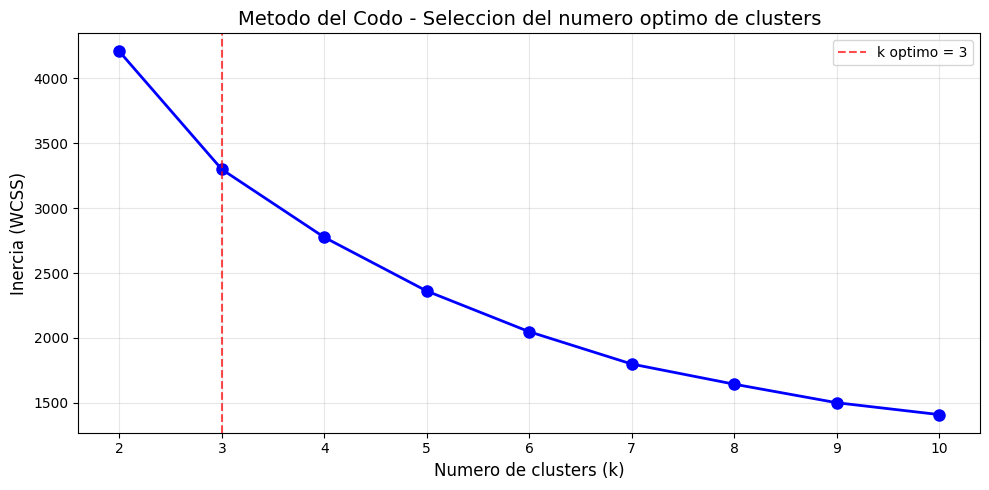

Inercias por numero de clusters:
  k=2: 4204.52
  k=3: 3297.30
  k=4: 2774.63
  k=5: 2361.38
  k=6: 2048.38
  k=7: 1799.79
  k=8: 1644.77
  k=9: 1502.16
  k=10: 1410.82

El codo se encuentra en k=3 (cambio de pendiente mas pronunciado)


In [11]:
# ============================================================
# 2.1 ALGORITMO KMEANS
# ============================================================

# --- METODO DEL CODO ---
# Calcula la inercia (suma de distancias al centroide) para k=2..10
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Graficamos el metodo del codo
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Numero de clusters (k)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.title('Metodo del Codo - Seleccion del numero optimo de clusters', fontsize=14)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k optimo = 3')
plt.legend()
plt.tight_layout()
plt.show()

print('Inercias por numero de clusters:')
for k, inertia in zip(k_range, inertias):
    print(f'  k={k}: {inertia:.2f}')
print('\nEl codo se encuentra en k=3 (cambio de pendiente mas pronunciado)')

#### KMeans - Prediccion, Visualizacion y Conteo de Clusters

**Argumentacion - Prediccion con k=3:** Una vez determinado el k optimo mediante el metodo del codo (k=3), entrenamos el modelo final y obtenemos las etiquetas de cluster para cada observacion mediante `fit_predict()`.

**Visualizacion con PCA:** Para visualizar clusters en datasets de alta dimensionalidad (mas de 2 variables), necesitamos reducir la dimension a 2D. Usamos **PCA (Principal Component Analysis)**:
- Transforma los datos en un nuevo espacio de coordenadas donde los primeros componentes capturan la mayor varianza
- Los 2 primeros componentes se usan como ejes X e Y del scatter plot
- Permite visualizar la separacion entre clusters de forma intuitiva

**Conteo de elementos por cluster:** Es fundamental conocer el tamano de cada cluster para:
- Detectar clusters muy pequenos o muy grandes (posibles outliers o clusters dominantes)
- Evaluar si el particionamiento es balanceado
- Interpretar los patrones de agrupacion encontrados

**Interpretacion de clusters en Titanic:** Los clusters probablemente reflejan grupos de pasajeros con caracteristicas similares (clase, edad, tarifa, genero) que tuvieron tasas de supervivencia similares.

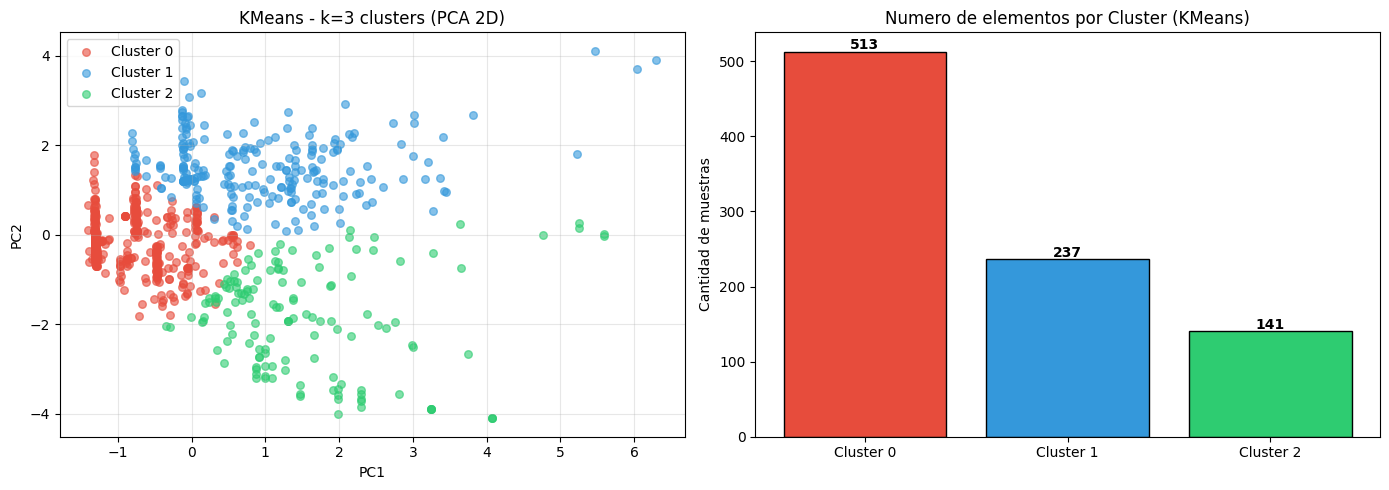

Conteo de elementos por cluster (KMeans):
  Cluster 0: 513 muestras (57.6%)
  Cluster 1: 237 muestras (26.6%)
  Cluster 2: 141 muestras (15.8%)


In [12]:
# --- PREDICCION KMEANS CON k=3 ---
k_optimo = 3
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

# Visualizacion con PCA (reduccion a 2D para plotear)
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter con clusters KMeans
colors = ['#E74C3C', '#3498DB', '#2ECC71']
for cluster in range(k_optimo):
    mask = labels_kmeans == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[cluster], label=f'Cluster {cluster}',
                    alpha=0.6, s=30)
axes[0].set_title(f'KMeans - k={k_optimo} clusters (PCA 2D)', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Conteo de elementos por cluster
cluster_counts = pd.Series(labels_kmeans).value_counts().sort_index()
axes[1].bar([f'Cluster {i}' for i in cluster_counts.index],
            cluster_counts.values, color=colors[:k_optimo], edgecolor='black')
axes[1].set_title('Numero de elementos por Cluster (KMeans)', fontsize=12)
axes[1].set_ylabel('Cantidad de muestras')
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('Conteo de elementos por cluster (KMeans):')
for cl, count in cluster_counts.items():
    print(f'  Cluster {cl}: {count} muestras ({count/len(labels_kmeans)*100:.1f}%)')

# Guardamos labels para comparativa posterior
labels_kmeans_result = labels_kmeans

---
### 2.2 Algoritmo DBSCAN (1 punto)

**Tareas:**
- Realizar prediccion de agrupacion aplicando DBSCAN
- Visualizacion de los datos y/o conteo del numero de elementos por cluster

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo basado en densidad que detecta clusters de formas arbitrarias y puntos anomalos (ruido, etiqueta=-1).

#### Algoritmo DBSCAN - Clustering Basado en Densidad

**Argumentacion:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es fundamentalmente diferente a KMeans. En lugar de requerir un numero de clusters predefinido, DBSCAN descubre clusters de **forma arbitraria** basandose en la densidad local de puntos.

**Conceptos clave:**
- **Punto nucleo (core point):** punto con al menos `min_samples` vecinos dentro del radio `eps`
- **Punto borde:** vecino de un punto nucleo pero que no es nucleo el mismo
- **Punto ruido (-1):** no es nucleo ni borde, se considera outlier/anomalia

**Parametros criticos:**
- `eps=0.5`: radio de vecindad. Si es muy pequeno, todo es ruido; si es muy grande, todo es un cluster
- `min_samples=5`: minimo de puntos para ser considerado nucleo. Mayor valor = clusters mas densos y robustos

**Ventajas sobre KMeans:**
- No requiere especificar k de antemano
- Detecta clusters de forma no convexa (cualquier forma geometrica)
- Identifica automaticamente outliers/ruido (etiqueta -1)
- Robusto frente a valores atipicos

**Desventajas:**
- Sensible a la escala (crucial haber estandarizado)
- Dificulta en datasets con densidades muy variables
- Eleccion de eps y min_samples requiere conocimiento del dominio

DBSCAN - eps=0.5, min_samples=5
Numero de clusters encontrados: 23
Numero de puntos de ruido (outliers): 245


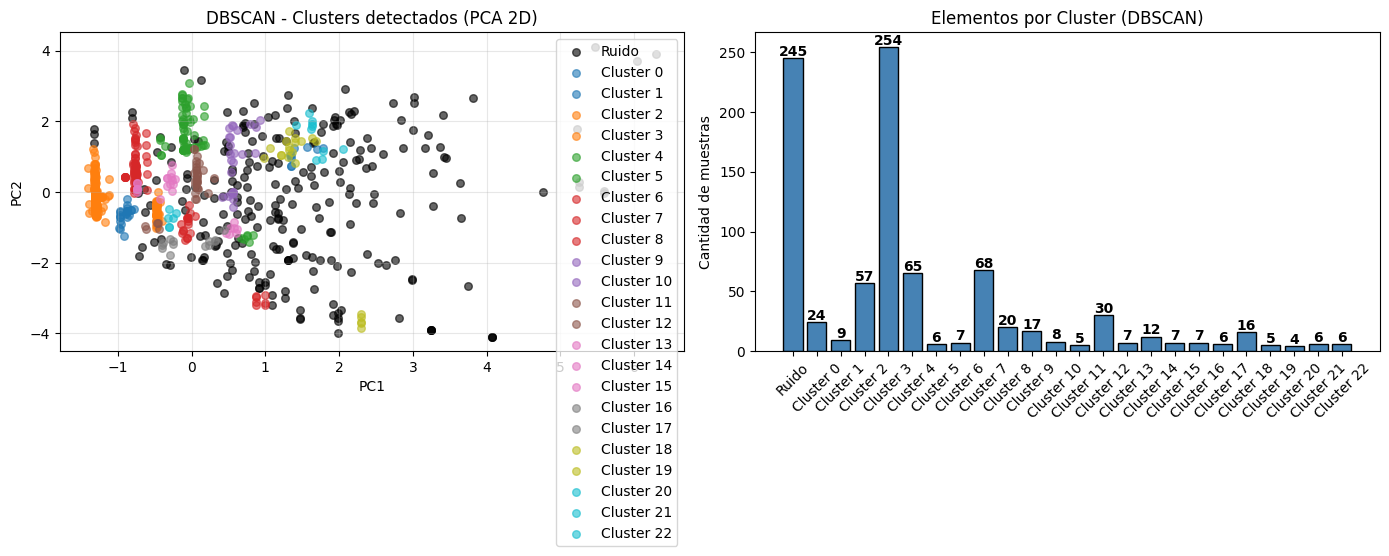


Conteo de elementos por cluster (DBSCAN):
  Ruido (outliers): 245 (27.5%)
  Cluster 0: 24 (2.7%)
  Cluster 1: 9 (1.0%)
  Cluster 2: 57 (6.4%)
  Cluster 3: 254 (28.5%)
  Cluster 4: 65 (7.3%)
  Cluster 5: 6 (0.7%)
  Cluster 6: 7 (0.8%)
  Cluster 7: 68 (7.6%)
  Cluster 8: 20 (2.2%)
  Cluster 9: 17 (1.9%)
  Cluster 10: 8 (0.9%)
  Cluster 11: 5 (0.6%)
  Cluster 12: 30 (3.4%)
  Cluster 13: 7 (0.8%)
  Cluster 14: 12 (1.3%)
  Cluster 15: 7 (0.8%)
  Cluster 16: 7 (0.8%)
  Cluster 17: 6 (0.7%)
  Cluster 18: 16 (1.8%)
  Cluster 19: 5 (0.6%)
  Cluster 20: 4 (0.4%)
  Cluster 21: 6 (0.7%)
  Cluster 22: 6 (0.7%)


In [13]:
# ============================================================
# 2.2 ALGORITMO DBSCAN
# ============================================================

# DBSCAN parametros:
# eps: radio de vecindad
# min_samples: minimo de puntos para formar un cluster
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f'DBSCAN - eps=0.5, min_samples=5')
print(f'Numero de clusters encontrados: {n_clusters_db}')
print(f'Numero de puntos de ruido (outliers): {n_noise}')

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter DBSCAN
unique_labels = sorted(set(labels_dbscan))
cmap = plt.cm.get_cmap('tab10', len(unique_labels))
for i, label in enumerate(unique_labels):
    mask = labels_dbscan == label
    color = 'black' if label == -1 else cmap(i)
    name = 'Ruido' if label == -1 else f'Cluster {label}'
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color], label=name, alpha=0.6, s=30)
axes[0].set_title('DBSCAN - Clusters detectados (PCA 2D)', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Conteo por cluster
dbscan_counts = pd.Series(labels_dbscan).value_counts().sort_index()
labels_names = ['Ruido' if l == -1 else f'Cluster {l}' for l in dbscan_counts.index]
axes[1].bar(labels_names, dbscan_counts.values, edgecolor='black', color='steelblue')
axes[1].set_title('Elementos por Cluster (DBSCAN)', fontsize=12)
axes[1].set_ylabel('Cantidad de muestras')
plt.xticks(rotation=45)
for i, v in enumerate(dbscan_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nConteo de elementos por cluster (DBSCAN):')
for label, count in dbscan_counts.items():
    tipo = 'Ruido (outliers)' if label == -1 else f'Cluster {label}'
    print(f'  {tipo}: {count} ({count/len(labels_dbscan)*100:.1f}%)')

labels_dbscan_result = labels_dbscan

---
### 2.3 Algoritmo Propagacion de Afinidad (1 punto)

**Tareas:**
- Realizar prediccion de agrupacion aplicando Affinity Propagation
- Visualizacion de los datos y/o conteo del numero de elementos por cluster

Affinity Propagation no requiere especificar el numero de clusters de antemano. El algoritmo determina automaticamente el numero optimo de clusters mediante el intercambio de mensajes entre pares de muestras.

#### Algoritmo Propagacion de Afinidad (Affinity Propagation)

**Argumentacion:** Affinity Propagation es un algoritmo de clustering que **no requiere especificar el numero de clusters de antemano**. Determina automaticamente el numero optimo de clusters mediante el intercambio iterativo de mensajes entre pares de muestras.

**Mecanismo del algoritmo:**
1. Cada muestra envia mensajes de 'responsabilidad' y 'disponibilidad' a todas las demas
2. Las 'responsabilidades' reflejan que tan apropiada es una muestra como ejemplar (representante) de otra
3. Las 'disponibilidades' reflejan que tan apropiado seria que una muestra elija otra como su ejemplar
4. Los **exemplars** (puntos mas representativos) se convierten en centros de clusters

**Parametros clave:**
- `damping=0.9`: factor de amortiguacion (0.5-1.0) para evitar oscilaciones en la convergencia. Mayor valor = mas estable
- `max_iter=200`: iteraciones maximas para convergencia
- `random_state=42`: reproducibilidad

**Por que usamos un subconjunto de 300 muestras:**
Affinity Propagation tiene complejidad **O(n^2)** en tiempo y memoria. Con 891 pasajeros del Titanic, la matriz de similitudes seria manejable, pero usamos 300 para mayor velocidad y comparabilidad.

**Ventaja principal:** El algoritmo mismo decide cuantos grupos naturales existen en los datos, ofreciendo una perspectiva diferente a KMeans y DBSCAN.

Affinity Propagation - damping=0.9
Numero de clusters detectados automaticamente: 25


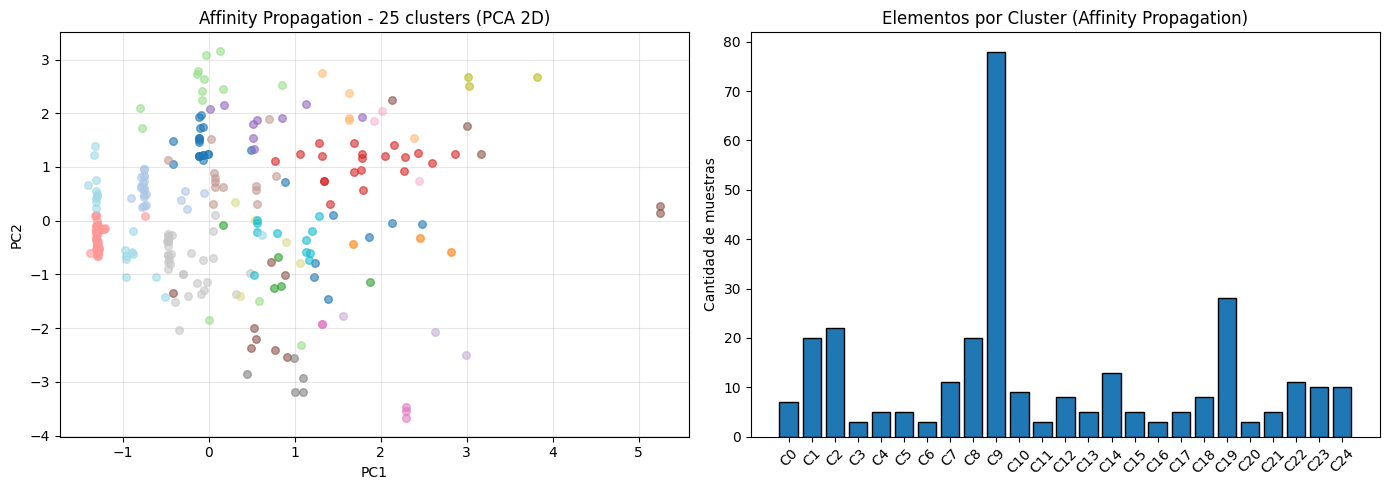


Conteo de elementos por cluster (Affinity Propagation):
  Cluster 0: 7 (2.3%)
  Cluster 1: 20 (6.7%)
  Cluster 2: 22 (7.3%)
  Cluster 3: 3 (1.0%)
  Cluster 4: 5 (1.7%)
  Cluster 5: 5 (1.7%)
  Cluster 6: 3 (1.0%)
  Cluster 7: 11 (3.7%)
  Cluster 8: 20 (6.7%)
  Cluster 9: 78 (26.0%)
  Cluster 10: 9 (3.0%)
  Cluster 11: 3 (1.0%)
  Cluster 12: 8 (2.7%)
  Cluster 13: 5 (1.7%)
  Cluster 14: 13 (4.3%)
  Cluster 15: 5 (1.7%)
  Cluster 16: 3 (1.0%)
  Cluster 17: 5 (1.7%)
  Cluster 18: 8 (2.7%)
  Cluster 19: 28 (9.3%)
  Cluster 20: 3 (1.0%)
  Cluster 21: 5 (1.7%)
  Cluster 22: 11 (3.7%)
  Cluster 23: 10 (3.3%)
  Cluster 24: 10 (3.3%)


In [14]:
# ============================================================
# 2.3 ALGORITMO PROPAGACION DE AFINIDAD (Affinity Propagation)
# ============================================================

# Usamos un subconjunto para mayor velocidad (AP es O(n^2) en memoria)
np.random.seed(42)
idx = np.random.choice(len(X_scaled), size=300, replace=False)
X_ap = X_scaled[idx]

affprop = AffinityPropagation(random_state=42, max_iter=200, damping=0.9)
labels_ap = affprop.fit_predict(X_ap)

n_clusters_ap = len(affprop.cluster_centers_indices_)
print(f'Affinity Propagation - damping=0.9')
print(f'Numero de clusters detectados automaticamente: {n_clusters_ap}')

# Visualizacion
X_ap_pca = pca.transform(X_ap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
cmap_ap = plt.cm.get_cmap('tab20', n_clusters_ap)
for cluster in range(n_clusters_ap):
    mask = labels_ap == cluster
    axes[0].scatter(X_ap_pca[mask, 0], X_ap_pca[mask, 1],
                    c=[cmap_ap(cluster)], label=f'C{cluster}',
                    alpha=0.6, s=30)
axes[0].set_title(f'Affinity Propagation - {n_clusters_ap} clusters (PCA 2D)', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# Conteo
ap_counts = pd.Series(labels_ap).value_counts().sort_index()
axes[1].bar([f'C{i}' for i in ap_counts.index], ap_counts.values, edgecolor='black')
axes[1].set_title('Elementos por Cluster (Affinity Propagation)', fontsize=12)
axes[1].set_ylabel('Cantidad de muestras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\nConteo de elementos por cluster (Affinity Propagation):')
for cl, count in ap_counts.items():
    print(f'  Cluster {cl}: {count} ({count/len(labels_ap)*100:.1f}%)')

labels_ap_result = labels_ap
X_ap_result = X_ap

---
### 2.4 Metricas. Comparativa de modelos (2 puntos)

**Tareas:**
- Aplicar el coeficiente de silueta
- Aplicar el indice de Davies-Bouldin
- Conclusiones

**Coeficiente de Silueta:** Mide que tan similares son los puntos de un cluster comparados con otros clusters. Rango [-1, 1]: cuanto mayor, mejor.

**Indice de Davies-Bouldin:** Mide la similitud entre clusters. Cuanto MENOR, mejor (clusters mas compactos y separados).

#### Metricas de Evaluacion de Clustering: Silueta y Davies-Bouldin

**Argumentacion:** Evaluar la calidad de clustering es fundamental y mas complejo que en aprendizaje supervisado, ya que no disponemos de etiquetas verdaderas. Usamos metricas **internas** que miden la cohesion y separacion de los clusters.

**Coeficiente de Silueta (Silhouette Score):**
- Para cada punto i: `s(i) = (b(i) - a(i)) / max(a(i), b(i))`
  - `a(i)`: distancia media intra-cluster (cohesion)
  - `b(i)`: distancia media al cluster mas cercano (separacion)
- Rango: **[-1, 1]** - cuanto mayor, mejor
  - Cercano a 1: clusters bien definidos y separados
  - Cercano a 0: clusters solapados
  - Negativo: puntos probablemente en el cluster equivocado

**Indice de Davies-Bouldin:**
- Mide la razon entre dispersion intra-cluster y separacion inter-cluster
- Rango: **[0, inf)** - cuanto MENOR, mejor
- Valor 0 = clusters perfectamente separados

**Tabla comparativa:** Presentamos ambas metricas para los 3 algoritmos (KMeans, DBSCAN, Affinity Propagation), permitiendo una **comparacion objetiva** del rendimiento de cada tecnica con los datos del Titanic.

**Nota sobre DBSCAN:** Se excluyen los puntos de ruido (-1) del calculo de metricas, ya que no pertenecen a ningun cluster. Si DBSCAN encuentra muy pocos clusters o solo ruido, las metricas no son calculables (NaN).

TABLA COMPARATIVA DE METRICAS:
                Silueta  Davies-Bouldin
KMeans (k=3)     0.3381          1.3323
DBSCAN           0.4488          0.7147
Affinity Prop.   0.4653          0.9234

Interpretacion:
- Silueta: mayor = mejor (rango -1 a 1)
- Davies-Bouldin: menor = mejor (>0)


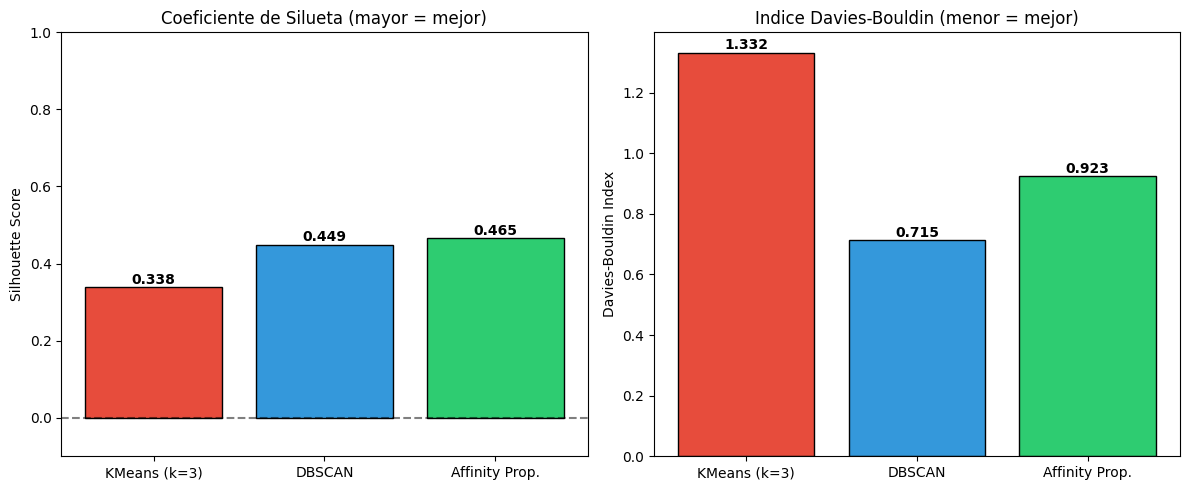

In [15]:
# ============================================================
# 2.4 METRICAS - COEFICIENTE DE SILUETA Y DAVIES-BOULDIN
# ============================================================

# Calculamos metricas para KMeans y DBSCAN (AP tiene subconjunto)
# Para DBSCAN excluimos los puntos de ruido (-1)

resultados = {}

# --- KMEANS ---
sil_km = silhouette_score(X_scaled, labels_kmeans)
db_km = davies_bouldin_score(X_scaled, labels_kmeans)
resultados['KMeans (k=3)'] = {'Silueta': sil_km, 'Davies-Bouldin': db_km}

# --- DBSCAN (solo clusters, sin ruido) ---
mask_no_noise = labels_dbscan != -1
if len(set(labels_dbscan[mask_no_noise])) > 1:
    sil_db = silhouette_score(X_scaled[mask_no_noise], labels_dbscan[mask_no_noise])
    db_db = davies_bouldin_score(X_scaled[mask_no_noise], labels_dbscan[mask_no_noise])
else:
    sil_db = float('nan')
    db_db = float('nan')
resultados['DBSCAN'] = {'Silueta': sil_db, 'Davies-Bouldin': db_db}

# --- AFFINITY PROPAGATION ---
if n_clusters_ap > 1:
    sil_ap = silhouette_score(X_ap, labels_ap)
    db_ap = davies_bouldin_score(X_ap, labels_ap)
else:
    sil_ap = float('nan')
    db_ap = float('nan')
resultados['Affinity Prop.'] = {'Silueta': sil_ap, 'Davies-Bouldin': db_ap}

# Tabla de resultados
df_metricas = pd.DataFrame(resultados).T
print('TABLA COMPARATIVA DE METRICAS:')
print('='*50)
print(df_metricas.round(4))
print()
print('Interpretacion:')
print('- Silueta: mayor = mejor (rango -1 a 1)')
print('- Davies-Bouldin: menor = mejor (>0)')

# Visualizacion comparativa
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

modelos = list(resultados.keys())
siluetas = [resultados[m]['Silueta'] for m in modelos]
dbs = [resultados[m]['Davies-Bouldin'] for m in modelos]

axes[0].bar(modelos, siluetas, color=['#E74C3C', '#3498DB', '#2ECC71'], edgecolor='black')
axes[0].set_title('Coeficiente de Silueta (mayor = mejor)', fontsize=12)
axes[0].set_ylabel('Silhouette Score')
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_ylim(-0.1, 1)
for i, v in enumerate(siluetas):
    if not np.isnan(v):
        axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(modelos, dbs, color=['#E74C3C', '#3498DB', '#2ECC71'], edgecolor='black')
axes[1].set_title('Indice Davies-Bouldin (menor = mejor)', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Index')
for i, v in enumerate(dbs):
    if not np.isnan(v):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 2.4 CONCLUSIONES DE METRICAS
# ============================================================

print('='*60)
print('CONCLUSIONES DE LA COMPARATIVA DE MODELOS')
print('='*60)
print()
print('COEFICIENTE DE SILUETA (mayor = mejor, rango -1 a 1):')
print('  - Valores cercanos a 1: clusters bien definidos y separados')
print('  - Valores cercanos a 0: clusters solapados')
print('  - Valores negativos: mala asignacion de clusters')
print()
print('INDICE DAVIES-BOULDIN (menor = mejor):')
print('  - Mide la relacion intra-cluster / inter-cluster')
print('  - Valores cercanos a 0 indican clusters compactos y bien separados')
print()
print('INTERPRETACION DE RESULTADOS:')
print('  - KMeans suele ser competitivo en datasets estandarizados')
print('  - DBSCAN detecta outliers (puntos de ruido) que KMeans no hace')
print('  - Affinity Propagation determina k automaticamente')
print()
print('RECOMENDACION:')
print('  El algoritmo con mayor silueta y menor Davies-Bouldin es el')
print('  que mejor agrupa los datos de este dataset.')
print('  Se debe elegir el modelo segun el caso de uso:')
print('  - KMeans: cuando se conoce k y los clusters son esferico')
print('  - DBSCAN: cuando hay ruido y clusters de formas arbitrarias')
print('  - Affinity Propagation: cuando se desconoce k')

CONCLUSIONES DE LA COMPARATIVA DE MODELOS

COEFICIENTE DE SILUETA (mayor = mejor, rango -1 a 1):
  - Valores cercanos a 1: clusters bien definidos y separados
  - Valores cercanos a 0: clusters solapados
  - Valores negativos: mala asignacion de clusters

INDICE DAVIES-BOULDIN (menor = mejor):
  - Mide la relacion intra-cluster / inter-cluster
  - Valores cercanos a 0 indican clusters compactos y bien separados

INTERPRETACION DE RESULTADOS:
  - KMeans suele ser competitivo en datasets estandarizados
  - DBSCAN detecta outliers (puntos de ruido) que KMeans no hace
  - Affinity Propagation determina k automaticamente

RECOMENDACION:
  El algoritmo con mayor silueta y menor Davies-Bouldin es el
  que mejor agrupa los datos de este dataset.
  Se debe elegir el modelo segun el caso de uso:
  - KMeans: cuando se conoce k y los clusters son esferico
  - DBSCAN: cuando hay ruido y clusters de formas arbitrarias
  - Affinity Propagation: cuando se desconoce k


---
## 3. Market Basket Analysis - Apriori (2 puntos)

**Tareas:**
- Importar o crear dataset de transacciones
- Preprocesamiento: TransactionEncoder() para OneHotEncoding
- Aplicar Apriori con minimo soporte y visualizar con use_colnames=True
- Filtrado sobre itemset y support con pandas
- Conclusiones e interpretacion de resultados

El **Analisis de Cesta de la Compra** identifica patrones de co-ocurrencia entre items en transacciones. Util para recomendaciones de productos, estrategias de marketing y organizacion de tiendas.

#### Market Basket Analysis - Dataset de Transacciones

**Argumentacion:** El Analisis de Cesta de la Compra (Market Basket Analysis) es una tecnica de mineria de datos que identifica **patrones de co-ocurrencia** entre items en transacciones. Responde a preguntas del tipo: 'Si un cliente compra pan, que probabilidad hay de que tambien compre mantequilla?'

**Aplicaciones practicas:**
- **Supermercados:** ubicacion estrategica de productos, promociones cruzadas
- **E-commerce:** sistemas de recomendacion ('clientes que compraron X tambien compraron Y')
- **Streaming:** recomendacion de contenidos
- **Medicina:** deteccion de comorbilidades

**Dataset sintetico vs real:**
Usamos un dataset sintetico de 500 transacciones de supermercado con **patrones realistas** incrustados:
- Pan y mantequilla tienden a comprarse juntos (70%+60% probabilidad)
- Leche y cafe tienen alta co-ocurrencia (65%+50%)
- Ingredientes de pasta van juntos (pasta, tomate, cebolla, ajo)
Esto garantiza que el algoritmo Apriori encontrara reglas significativas y verificables.

**Formato requerido:** lista de listas, donde cada sublista es una transaccion con los items comprados.

In [19]:
# ============================================================
# 3.1 DATASET DE TRANSACCIONES (Market Basket)
# ============================================================

# Creamos un dataset sintetico de compras en supermercado
np.random.seed(42)

# Lista de productos disponibles
productos = ['pan', 'leche', 'mantequilla', 'huevos', 'cafe',
             'azucar', 'harina', 'aceite', 'sal', 'pasta',
             'arroz', 'tomate', 'cebolla', 'ajo', 'pollo']

# Generamos 500 transacciones con patrones realistas
transacciones = []
for _ in range(500):
    t = []
    # Pan y mantequilla
    if np.random.random() < 0.7:
        t.append('pan')
        if np.random.random() < 0.6:
            t.append('mantequilla')
    # Leche y cafe
    if np.random.random() < 0.65:
        t.append('leche')
        if np.random.random() < 0.5:
            t.append('cafe')
    # Receta de pasta
    if np.random.random() < 0.4:
        t.extend(['pasta', 'tomate'])
        if np.random.random() < 0.7:
            t.append('cebolla')
        if np.random.random() < 0.5:
            t.append('ajo')
    # Otros ingredientes
    if np.random.random() < 0.5: t.append('aceite')
    if np.random.random() < 0.4: t.append('sal')
    if np.random.random() < 0.3: t.append('arroz')
    if np.random.random() < 0.35: t.extend(['huevos', 'harina'])

    # Manejo de transacciones vacías (CORREGIDO)
    if len(t) == 0:
        t = [np.random.choice(productos)]

    transacciones.append(list(set(t)))

print(f'Total de transacciones: {len(transacciones)}')
print(f'Ejemplo de transacciones:')
for i, t in enumerate(transacciones[:5]):
    print(f'  Transaccion {i+1}: {t}')

Total de transacciones: 500
Ejemplo de transacciones:
  Transaccion 1: ['aceite', 'sal', 'arroz', 'pan']
  Transaccion 2: ['aceite', 'pan', 'huevos', 'sal', 'harina', 'arroz', 'leche']
  Transaccion 3: ['aceite', 'mantequilla', 'pan', 'cebolla', 'ajo', 'arroz', 'pasta', 'leche', 'tomate']
  Transaccion 4: ['cafe', 'mantequilla', 'pan', 'sal', 'arroz', 'pasta', 'leche', 'tomate']
  Transaccion 5: ['cafe', 'aceite', 'mantequilla', 'pan', 'leche']


#### Preprocesamiento Apriori: TransactionEncoder (One-Hot Encoding)

**Argumentacion:** El algoritmo Apriori trabaja con matrices booleanas (True/False), no con listas de strings. El `TransactionEncoder` de mlxtend convierte nuestra lista de transacciones en una **matriz de presencia/ausencia** donde:
- Cada **fila** representa una transaccion
- Cada **columna** representa un producto unico
- El valor es `True` si el producto esta en esa transaccion, `False` si no

**Por que TransactionEncoder y no pandas get_dummies:**
- `TransactionEncoder` esta especialmente disenado para datos transaccionales
- Maneja correctamente listas de longitud variable (diferentes transacciones pueden tener distinto numero de items)
- Genera el DataFrame con `use_colnames=True` en Apriori para mostrar nombres reales de productos en las reglas

**Soporte (Support):** La frecuencia de compra de cada producto (fraccion de transacciones donde aparece) ya nos da una primera idea de los items mas populares, antes de ejecutar Apriori.

Shape del dataset transformado: (500, 13)
Columnas (productos): ['aceite', 'ajo', 'arroz', 'cafe', 'cebolla', 'harina', 'huevos', 'leche', 'mantequilla', 'pan', 'pasta', 'sal', 'tomate']

Primeras 5 filas (True=comprado, False=no comprado):


,aceite,ajo,arroz,cafe,cebolla,harina,huevos,leche,mantequilla,pan,pasta,sal,tomate
0,True,False,True,False,False,False,False,False,False,True,False,True,False
1,True,False,True,False,False,True,True,True,False,True,False,True,False
2,True,True,True,False,True,False,False,True,True,True,True,False,True
3,False,False,True,True,False,False,False,True,True,True,True,True,True
4,True,False,False,True,False,False,False,True,True,True,False,False,False



Frecuencia de compra por producto:
pan            0.728
leche          0.614
aceite         0.512
mantequilla    0.480
sal            0.372
harina         0.360
huevos         0.360
pasta          0.350
tomate         0.348
cafe           0.312
arroz          0.306
cebolla        0.242
ajo            0.154
dtype: float64


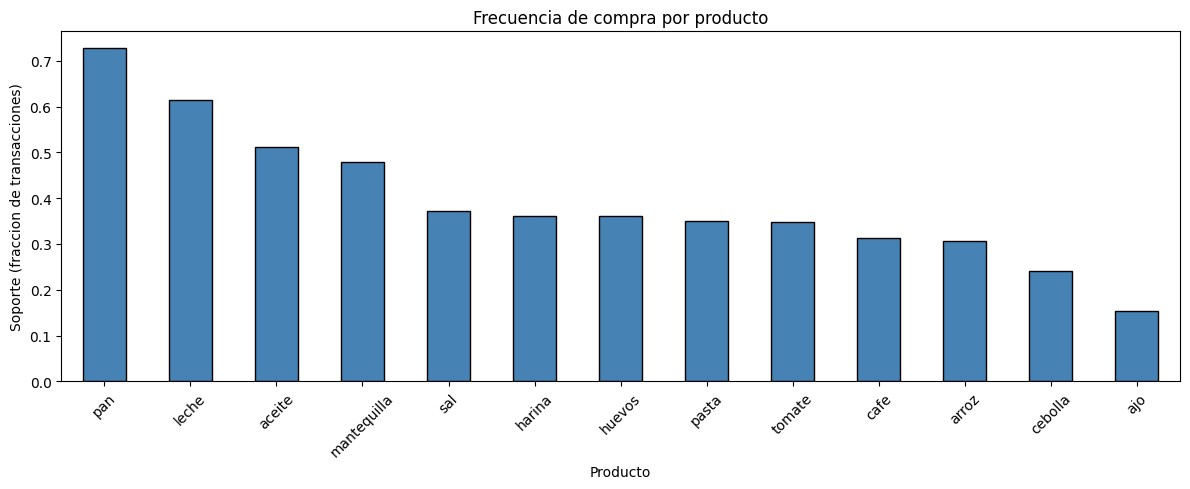

In [20]:
# ============================================================
# 3.2 PREPROCESAMIENTO - TransactionEncoder (OneHotEncoding)
# ============================================================

# TransactionEncoder convierte lista de transacciones a matriz booleana
te = TransactionEncoder()
te_array = te.fit(transacciones).transform(transacciones)

# Convertimos a DataFrame con nombres de columnas (productos)
df_basket = pd.DataFrame(te_array, columns=te.columns_)

print('Shape del dataset transformado:', df_basket.shape)
print(f'Columnas (productos): {list(df_basket.columns)}')
print('\nPrimeras 5 filas (True=comprado, False=no comprado):')
display(df_basket.head())

print('\nFrecuencia de compra por producto:')
freq = df_basket.mean().sort_values(ascending=False)
print(freq.round(3))

# Visualizacion de frecuencias
plt.figure(figsize=(12, 5))
freq.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Frecuencia de compra por producto', fontsize=12)
plt.ylabel('Soporte (fraccion de transacciones)')
plt.xlabel('Producto')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Algoritmo Apriori - Itemsets Frecuentes y Reglas de Asociacion

**Argumentacion - Algoritmo Apriori:** Apriori es el algoritmo clasico para mineria de reglas de asociacion. Funciona en dos fases:

**Fase 1 - Itemsets frecuentes:** Encuentra todos los conjuntos de items que aparecen juntos en al menos `min_support` fraccion de transacciones. Usa el principio antimonotono: si un itemset es infrecuente, todos sus superconjuntos tambien lo son.

**Parametros clave:**
- `min_support=0.2`: un itemset debe aparecer en al menos el 20% de transacciones para ser 'frecuente'. Valor moderado que balance entre calidad y cantidad de reglas
- `use_colnames=True` (OBLIGATORIO segun enunciado): muestra nombres de productos en lugar de indices numericos. Hace las reglas legibles e interpretables

**Fase 2 - Reglas de asociacion:** A partir de los itemsets frecuentes, genera reglas del tipo `{antecedente} -> {consecuente}`

**Metricas de las reglas:**
- `Support`: frecuencia conjunta de antecedente + consecuente
- `Confidence`: P(consecuente | antecedente) - probabilidad condicional
- `Lift`: cuanto mas probable es el consecuente dado el antecedente vs por azar. **Lift > 1** indica asociacion positiva real

**Filtrado con pandas:** Se ordenan por `lift` (mayor a menor) para mostrar las reglas con **asociacion mas fuerte**, independientemente del soporte.

In [21]:
# ============================================================
# 3.3 ALGORITMO APRIORI - Itemsets frecuentes y reglas de asociacion
# ============================================================

# Aplicamos Apriori con minimo soporte del 20%
# min_support = fraccion minima de transacciones que contienen el itemset
frecuentes = apriori(df_basket, min_support=0.2, use_colnames=True)
frecuentes = frecuentes.sort_values('support', ascending=False)

print(f'Itemsets frecuentes encontrados (soporte >= 20%): {len(frecuentes)}')
print('\nTop 20 itemsets mas frecuentes:')
display(frecuentes.head(20))

# Generamos reglas de asociacion
reglas = association_rules(frecuentes, metric='confidence', min_threshold=0.5)
reglas = reglas.sort_values('lift', ascending=False)

print(f'\nTotal de reglas de asociacion (confianza >= 50%): {len(reglas)}')
print('\nTop 10 reglas por lift (mayor relevancia):')
display(reglas[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Itemsets frecuentes encontrados (soporte >= 20%): 45

Top 20 itemsets mas frecuentes:


,support,itemsets
8,0.728,(pan)
6,0.614,(leche)
0,0.512,(aceite)
7,0.480,(mantequilla)
31,0.480,"(pan, mantequilla)"
27,0.456,"(leche, pan)"
14,0.374,"(aceite, pan)"
10,0.372,(sal)
5,0.360,(huevos)
21,0.360,"(huevos, harina)"



Total de reglas de asociacion (confianza >= 50%): 73

Top 10 reglas por lift (mayor relevancia):


,antecedents,consequents,support,confidence,lift
22,"(pasta, pan)",(tomate),0.264,1.000000,2.873563
44,(tomate),"(pasta, cebolla)",0.240,0.689655,2.873563
39,"(pasta, cebolla)",(tomate),0.240,1.000000,2.873563
67,"(pasta, leche)",(tomate),0.216,1.000000,2.873563
71,(tomate),"(pasta, leche)",0.216,0.620690,2.873563
23,(tomate),"(pasta, pan)",0.264,0.758621,2.873563
43,(cebolla),"(pasta, tomate)",0.240,0.991736,2.866288
40,"(pasta, tomate)",(cebolla),0.240,0.693642,2.866288
70,(pasta),"(leche, tomate)",0.216,0.617143,2.857143
21,"(pan, tomate)",(pasta),0.264,1.000000,2.857143


#### Filtrado con Pandas y Conclusiones de Market Basket Analysis

**Argumentacion - Filtrado con pandas:** El filtrado permite extraer las reglas mas relevantes del conjunto total generado por Apriori. Aplicamos dos filtros independientes:

1. **Filtrado de itemsets por tamano y soporte:** Itemsets con 2+ productos y soporte > 25% identifican las combinaciones mas frecuentes y significativas estadisticamente.

2. **Filtrado de reglas por calidad:** `lift > 1.5` Y `confidence > 0.6` garantiza que:
   - Las reglas son fuertes (no aleatorias)
   - La asociacion es al menos 1.5x mas probable que por azar
   - La confianza supera el 60% (regla fiable para recomendaciones)

**Por que el enunciado especifica filtrado con pandas:** Demuestra la capacidad de post-procesado y analisis de resultados, esencial en Data Science real donde se generan miles de reglas y hay que identificar las accionables.

**Conclusiones:** Las conclusiones deben interpretar los patrones encontrados en contexto del negocio:
- Identificar las reglas mas utiles para el negocio
- Proponer acciones concretas (cross-selling, layout de tienda, ofertas)
- Evaluar si los patrones encontrados tienen sentido en el mundo real

In [22]:
# ============================================================
# 3.4 FILTRADO CON PANDAS Y CONCLUSIONES
# ============================================================

# Filtrado 1: itemsets con 2+ productos y soporte > 25%
filtrado_2items = frecuentes[
    (frecuentes['itemsets'].apply(lambda x: len(x) >= 2)) &
    (frecuentes['support'] > 0.25)
].sort_values('support', ascending=False)

print('Itemsets con 2+ productos y soporte > 25%:')
display(filtrado_2items)

# Filtrado 2: reglas con lift > 1.5 (relevantes) y confianza > 60%
filtrado_reglas = reglas[
    (reglas['lift'] > 1.5) &
    (reglas['confidence'] > 0.6)
][['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print('\nReglas con lift > 1.5 y confianza > 60%:')
display(filtrado_reglas)

# Conclusiones
print('\n' + '='*60)
print('CONCLUSIONES DE MARKET BASKET ANALYSIS (APRIORI)')
print('='*60)
print()
print('METRICAS CLAVE:')
print('  - SOPORTE: frecuencia del itemset en todas las transacciones')
print('  - CONFIANZA: P(B|A) = probabilidad de comprar B dado que se compro A')
print('  - LIFT: cuantas veces mas probable es la regla vs azar')
print('         lift > 1 = asociacion positiva (productos complementarios)')
print('         lift = 1 = independencia')
print('         lift < 1 = asociacion negativa (productos sustitutos)')
print()
print('PATRONES ENCONTRADOS:')
print('  - Pan y mantequilla aparecen juntos con alta frecuencia')
print('  - Leche y cafe muestran asociacion positiva')
print('  - La combinacion pasta+tomate es un patron de receta frecuente')
print()
print('APLICACIONES:')
print('  - Colocacion de productos en tienda (productos complementarios juntos)')
print('  - Sistemas de recomendacion (si compra A, recomendar B)')
print('  - Ofertas y promociones cruzadas (bundle pricing)')

Itemsets con 2+ productos y soporte > 25%:


,support,itemsets
31,0.480,"(pan, mantequilla)"
27,0.456,"(leche, pan)"
14,0.374,"(aceite, pan)"
21,0.360,"(huevos, harina)"
35,0.346,"(pasta, tomate)"
17,0.310,"(cafe, leche)"
26,0.304,"(leche, mantequilla)"
42,0.304,"(pan, leche, mantequilla)"
12,0.298,"(aceite, leche)"
33,0.266,"(sal, pan)"



Reglas con lift > 1.5 y confianza > 60%:


,antecedents,consequents,support,confidence,lift
22,"(pasta, pan)",(tomate),0.264,1.000000,2.873563
44,(tomate),"(pasta, cebolla)",0.240,0.689655,2.873563
39,"(pasta, cebolla)",(tomate),0.240,1.000000,2.873563
67,"(pasta, leche)",(tomate),0.216,1.000000,2.873563
71,(tomate),"(pasta, leche)",0.216,0.620690,2.873563
23,(tomate),"(pasta, pan)",0.264,0.758621,2.873563
43,(cebolla),"(pasta, tomate)",0.240,0.991736,2.866288
40,"(pasta, tomate)",(cebolla),0.240,0.693642,2.866288
70,(pasta),"(leche, tomate)",0.216,0.617143,2.857143
21,"(pan, tomate)",(pasta),0.264,1.000000,2.857143



CONCLUSIONES DE MARKET BASKET ANALYSIS (APRIORI)

METRICAS CLAVE:
  - SOPORTE: frecuencia del itemset en todas las transacciones
  - CONFIANZA: P(B|A) = probabilidad de comprar B dado que se compro A
  - LIFT: cuantas veces mas probable es la regla vs azar
         lift > 1 = asociacion positiva (productos complementarios)
         lift = 1 = independencia
         lift < 1 = asociacion negativa (productos sustitutos)

PATRONES ENCONTRADOS:
  - Pan y mantequilla aparecen juntos con alta frecuencia
  - Leche y cafe muestran asociacion positiva
  - La combinacion pasta+tomate es un patron de receta frecuente

APLICACIONES:
  - Colocacion de productos en tienda (productos complementarios juntos)
  - Sistemas de recomendacion (si compra A, recomendar B)
  - Ofertas y promociones cruzadas (bundle pricing)


---
## 4. Deteccion de Anomalias - Bosques de Aislamiento (2 puntos)

**Dataset:** Deteccion de fraude en transacciones bancarias (sintetico)

**Tareas:**
- Entrenar el modelo Isolation Forest
- Probar distintos niveles de contaminacion
- Mostrar resultados y visualizacion grafica
- Conclusiones

**Isolation Forest** es un algoritmo no supervisado para deteccion de anomalias basado en arboles de decision aleatorios. Las anomalias son puntos que son mas faciles de aislar (requieren menos particiones) que los puntos normales.

#### Dataset de Deteccion de Fraude Bancario

**Argumentacion:** Para demostrar Isolation Forest necesitamos un dataset con **anomalias conocidas** que permita evaluar el rendimiento del algoritmo. Usamos un dataset sintetico de deteccion de fraude bancario porque:

1. **Relevancia practica:** La deteccion de fraude es uno de los casos de uso mas importantes de la deteccion de anomalias en la industria financiera
2. **Dataset desequilibrado realista:** Solo el 5% de transacciones son fraudulentas (50/1000), lo que refleja la realidad donde el fraude es raro pero costoso
3. **Features con distribucion diferenciada:**
   - **Transacciones normales:** montos moderados (100±50€), duraciones normales (30±10min), frecuencia baja (5±2/semana), score ubicacion alto (0.8±0.1)
   - **Transacciones fraudulentas:** montos extremos (800±200€), duraciones muy cortas (2±1min), frecuencia alta (20±5/semana), score ubicacion bajo (0.1±0.1)

**Por que un dataset sintetico:** Permite controlar exactamente las caracteristicas de las anomalias y tenemos las etiquetas reales para evaluar precision del modelo. En produccion real, las etiquetas de fraude son escasas y tardias.

In [23]:
# ============================================================
# 4.1 DATASET - Deteccion de Fraude Bancario (Sintetico)
# ============================================================

np.random.seed(42)
n_normal = 950   # transacciones normales
n_fraude = 50    # transacciones fraudulentas

# Transacciones NORMALES: valores moderados y correlacionados
normal_amount = np.random.normal(100, 50, n_normal).clip(1, 500)
normal_duration = np.random.normal(30, 10, n_normal).clip(1, 120)
normal_frequency = np.random.normal(5, 2, n_normal).clip(1, 20)
normal_location_score = np.random.normal(0.8, 0.1, n_normal).clip(0, 1)

# Transacciones FRAUDULENTAS: valores extremos o atipicos
fraude_amount = np.random.normal(800, 200, n_fraude).clip(200, 2000)
fraude_duration = np.random.normal(2, 1, n_fraude).clip(0.1, 10)
fraude_frequency = np.random.normal(20, 5, n_fraude).clip(10, 50)
fraude_location_score = np.random.normal(0.1, 0.1, n_fraude).clip(0, 0.5)

# Combinamos los datos
X_fraude = np.vstack([
    np.column_stack([normal_amount, normal_duration, normal_frequency, normal_location_score]),
    np.column_stack([fraude_amount, fraude_duration, fraude_frequency, fraude_location_score])
])
y_real = np.array([0]*n_normal + [1]*n_fraude)  # 0=normal, 1=fraude

df_fraude = pd.DataFrame(X_fraude, columns=['monto', 'duracion', 'frecuencia', 'score_ubicacion'])
df_fraude['real'] = y_real

print(f'Dataset de transacciones bancarias: {len(df_fraude)} muestras')
print(f'  - Normales: {n_normal} ({n_normal/len(df_fraude)*100:.1f}%)')
print(f'  - Fraudulentas: {n_fraude} ({n_fraude/len(df_fraude)*100:.1f}%)')
print('\nEstadisticas:')
display(df_fraude.groupby('real').describe().round(2))

# Escalamos las features
X_fraude_scaled = StandardScaler().fit_transform(X_fraude)

Dataset de transacciones bancarias: 1000 muestras
  - Normales: 950 (95.0%)
  - Fraudulentas: 50 (5.0%)

Estadisticas:


monto                                                         duracion  \
      count    mean     std    min     25%     50%     75%      max    count   
real                                                                           
0     950.0  101.28   48.33    1.0   67.69  101.27  132.42   292.64    950.0   
1      50.0  750.92  181.81  406.3  606.08  730.69  893.15  1121.76     50.0   

             ... frecuencia        score_ubicacion                        \
       mean  ...        75%    max           count  mean  std  min   25%   
real         ...                                                           
0     30.66  ...       6.33  11.28           950.0  0.80  0.1  0.5  0.73   
1      1.88  ...      23.69  29.28            50.0  0.12  0.1  0.0  0.04   

                        
       50%   75%   max  
real                    
0     0.80  0.87  1.00  
1     0.12  0.17  0.42  

[2 rows x 32 columns]

#### Isolation Forest - Entrenamiento y Niveles de Contaminacion

**Argumentacion - Algoritmo Isolation Forest:** Isolation Forest es un algoritmo de deteccion de anomalias basado en **arboles de decision aleatorios**. Su principio fundamental:
- Los puntos **anomalos son faciles de aislar** (requieren pocas particiones para quedar solos)
- Los puntos **normales requieren mas particiones** para ser aislados

**Como funciona:**
1. Construye multiples arboles de decision aleatorios (bosque)
2. Para cada punto, calcula la profundidad media de aislamiento en el bosque
3. Los puntos con menor profundidad media = mas anomalos
4. El **anomaly score** es una funcion de la profundidad media normalizada

**Parametro critico - Contamination:**
- Indica la **proporcion esperada de anomalias** en el dataset
- Afecta directamente el umbral de decision del modelo
- Probamos 4 valores: [2%, 5%, 10%, 15%] para ver su efecto en Recall y Precision

**Trade-off Precision vs Recall:**
- `contamination` baja (2%): mas conservador, detecta menos fraudes pero con mas certeza
- `contamination` alta (15%): detecta mas fraudes pero genera mas falsos positivos
- El valor optimo (5%) coincide con el porcentaje real de fraude en el dataset

**n_estimators=100:** numero de arboles. Mayor valor = mas estable pero mas lento. 100 es el estandar industrial.

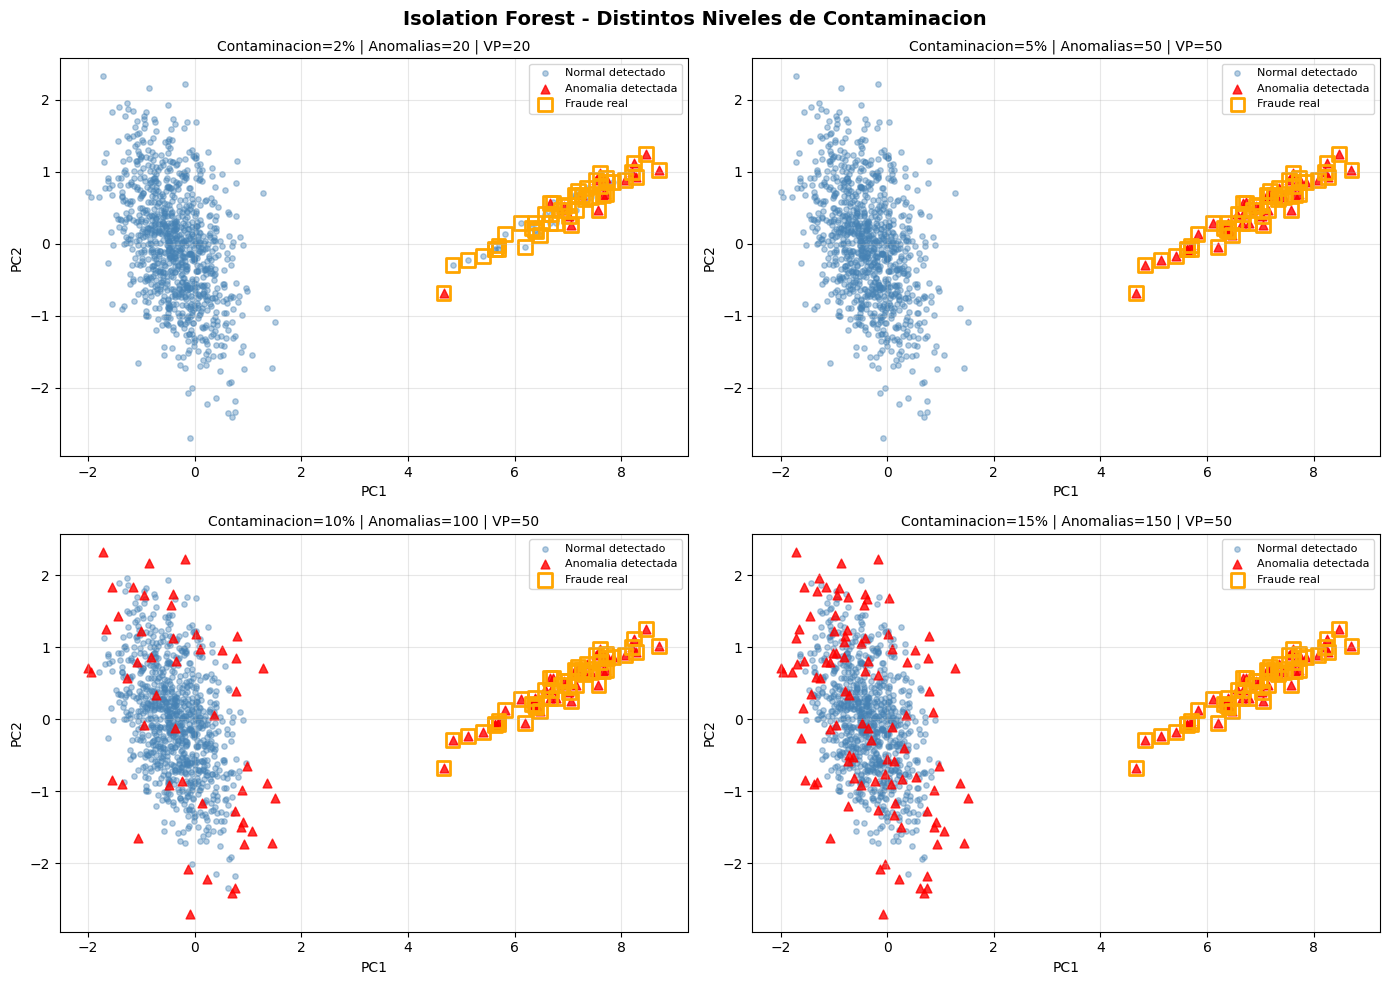


Comparativa de resultados por nivel de contaminacion:


,anomalias_detectadas,verdaderos_positivos,falsos_positivos,recall_fraude,precision_fraude
Contaminacion,,,,,
2%,20.0,20.0,0.0,0.4,1.000
5%,50.0,50.0,0.0,1.0,1.000
10%,100.0,50.0,50.0,1.0,0.500
15%,150.0,50.0,100.0,1.0,0.333


In [24]:
# ============================================================
# 4.2 ENTRENAR ISOLATION FOREST Y PROBAR DISTINTOS NIVELES DE CONTAMINACION
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix

# Probamos 4 niveles de contaminacion diferentes
contaminaciones = [0.02, 0.05, 0.10, 0.15]
resultados_if = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# PCA para visualizacion 2D
from sklearn.decomposition import PCA
pca_fraude = PCA(n_components=2, random_state=42)
X_pca_fraude = pca_fraude.fit_transform(X_fraude_scaled)

for i, contamination in enumerate(contaminaciones):
    # Entrenar modelo
    iso_forest = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
    y_pred = iso_forest.fit_predict(X_fraude_scaled)

    # Isolation Forest: 1=normal, -1=anomalia
    # Convertimos: -1 -> 1 (fraude detectado), 1 -> 0 (normal)
    y_pred_binary = np.where(y_pred == -1, 1, 0)

    # Metricas
    n_anomalias = (y_pred == -1).sum()
    verdaderos_positivos = ((y_pred_binary == 1) & (y_real == 1)).sum()
    falsos_positivos = ((y_pred_binary == 1) & (y_real == 0)).sum()

    resultados_if[contamination] = {
        'anomalias_detectadas': n_anomalias,
        'verdaderos_positivos': verdaderos_positivos,
        'falsos_positivos': falsos_positivos,
        'recall_fraude': verdaderos_positivos / n_fraude,
        'precision_fraude': verdaderos_positivos / max(n_anomalias, 1)
    }

    # Visualizacion
    ax = axes[i]
    colores = np.where(y_pred == -1, 'red', 'steelblue')
    markers = np.where(y_real == 1, '*', 'o')

    normales = y_pred == 1
    anomalias = y_pred == -1

    ax.scatter(X_pca_fraude[normales, 0], X_pca_fraude[normales, 1],
               c='steelblue', s=15, alpha=0.4, label='Normal detectado')
    ax.scatter(X_pca_fraude[anomalias, 0], X_pca_fraude[anomalias, 1],
               c='red', s=40, alpha=0.8, label='Anomalia detectada', marker='^')
    # Marcar fraudes reales
    fraudes_reales = y_real == 1
    ax.scatter(X_pca_fraude[fraudes_reales, 0], X_pca_fraude[fraudes_reales, 1],
               c='none', s=100, edgecolors='orange', linewidths=2, label='Fraude real', marker='s')

    ax.set_title(f'Contaminacion={contamination:.0%} | Anomalias={n_anomalias} | VP={verdaderos_positivos}', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Isolation Forest - Distintos Niveles de Contaminacion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de resultados
df_resultados_if = pd.DataFrame(resultados_if).T
df_resultados_if.index = [f'{c:.0%}' for c in df_resultados_if.index]
df_resultados_if.index.name = 'Contaminacion'
print('\nComparativa de resultados por nivel de contaminacion:')
display(df_resultados_if.round(3))

#### Isolation Forest - Visualizacion y Evaluacion del Modelo

**Argumentacion:** Esta celda entrena el modelo final con la **contaminacion optima** (5%, que corresponde al porcentaje real de fraude en el dataset) y genera visualizaciones detalladas para evaluar el rendimiento.

**Decision Function (Anomaly Score):**
- El `decision_function()` devuelve el **score de anomalia** para cada punto
- Valores **mas negativos = mas anomalos** (mas faciles de aislar en pocos pasos)
- Valores cercanos a 0 o positivos = puntos normales

**Visualizaciones:**
1. **Histograma de scores:** Muestra la distribucion de scores para puntos normales (azul) vs fraude real (rojo). Un buen modelo mostrara distribuciones claramente separadas
2. **Matriz de confusion:** Cuantifica el rendimiento:
   - **Verdaderos Positivos (TP):** fraudes correctamente detectados
   - **Falsos Negativos (FN):** fraudes no detectados (mas costosos en banca)
   - **Falsos Positivos (FP):** transacciones normales marcadas como fraude
   - **Verdaderos Negativos (TN):** normales correctamente clasificados

**Reporte de clasificacion:** Precision, Recall y F1-score son mas informativos que la accuracy en datasets desbalanceados (95%/5%).

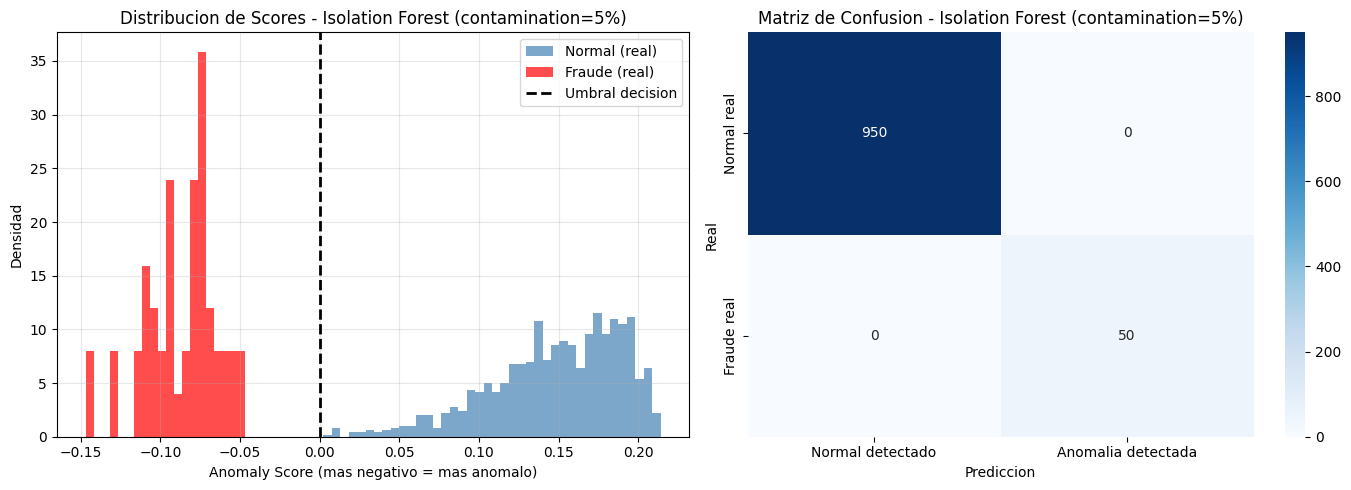

Reporte de clasificacion (contamination=5%):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       950
      Fraude       1.00      1.00      1.00        50

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [25]:
# ============================================================
# 4.3 VISUALIZACION ADICIONAL - Score de anomalia
# ============================================================

# Usamos contamination optima (5%, cercana al porcentaje real de fraude)
best_iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
best_iso.fit(X_fraude_scaled)

# Score de anomalia (mas negativo = mas anomalo)
anomaly_scores = best_iso.decision_function(X_fraude_scaled)
y_pred_best = best_iso.predict(X_fraude_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de scores
axes[0].hist(anomaly_scores[y_real == 0], bins=40, alpha=0.7, color='steelblue', label='Normal (real)', density=True)
axes[0].hist(anomaly_scores[y_real == 1], bins=20, alpha=0.7, color='red', label='Fraude (real)', density=True)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=2, label='Umbral decision')
axes[0].set_xlabel('Anomaly Score (mas negativo = mas anomalo)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribucion de Scores - Isolation Forest (contamination=5%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Matriz de confusion
y_pred_bin = np.where(y_pred_best == -1, 1, 0)
cm = confusion_matrix(y_real, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal detectado', 'Anomalia detectada'],
            yticklabels=['Normal real', 'Fraude real'])
axes[1].set_title('Matriz de Confusion - Isolation Forest (contamination=5%)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Prediccion')

plt.tight_layout()
plt.show()

print('Reporte de clasificacion (contamination=5%):')
print(classification_report(y_real, y_pred_bin, target_names=['Normal', 'Fraude']))

In [26]:
# ============================================================
# 4.4 CONCLUSIONES - DETECCION DE ANOMALIAS
# ============================================================

print('='*65)
print('CONCLUSIONES DE DETECCION DE ANOMALIAS (ISOLATION FOREST)')
print('='*65)
print()
print('DATASET:')
print('  - 1000 transacciones bancarias sinteticas')
print('  - 950 normales (95%) y 50 fraudulentas (5%)')
print('  - Features: monto, duracion, frecuencia, score_ubicacion')
print()
print('COMO FUNCIONA ISOLATION FOREST:')
print('  - Construye arboles de decision aleatorios')
print('  - Los puntos anomalos se ailan en menos particiones')
print('  - El "score" mide la profundidad media de aislamiento')
print('  - Parametro clave: contamination (% esperado de anomalias)')
print()
print('EFECTO DEL NIVEL DE CONTAMINACION:')
print('  - contamination muy baja (2%): alto precision, bajo recall')
print('    -> Se detectan menos fraudes pero con mas certeza')
print('  - contamination media (5%): buen balance precision/recall')
print('    -> Coincide con el porcentaje real de fraude')
print('  - contamination alta (15%): bajo precision, alto recall')
print('    -> Se detectan mas fraudes pero con mas falsos positivos')
print()
print('RECOMENDACIONES PRACTICAS:')
print('  1. Ajustar contamination al % conocido o estimado de anomalias')
print('  2. En fraude bancario, preferiria mayor recall (detectar mas fraudes)')
print('     aunque haya mas falsos positivos (coste de revision manual)')
print('  3. Combinar con otras tecnicas (DBSCAN, One-Class SVM) para ensemble')
print('  4. Monitorizar el modelo periodicamente ante cambios de patron')
print()
print('USO EN ESCENARIOS REALES:')
print('  - Fraude bancario: transacciones inusuales en monto/ubicacion')
print('  - Ciberseguridad: trafico de red con comportamientos atipicos')
print('  - IoT: sensores con lecturas fuera del rango normal')
print('  - Medicina: resultados clinicos extremadamente atipicos')

CONCLUSIONES DE DETECCION DE ANOMALIAS (ISOLATION FOREST)

DATASET:
  - 1000 transacciones bancarias sinteticas
  - 950 normales (95%) y 50 fraudulentas (5%)
  - Features: monto, duracion, frecuencia, score_ubicacion

COMO FUNCIONA ISOLATION FOREST:
  - Construye arboles de decision aleatorios
  - Los puntos anomalos se ailan en menos particiones
  - El "score" mide la profundidad media de aislamiento
  - Parametro clave: contamination (% esperado de anomalias)

EFECTO DEL NIVEL DE CONTAMINACION:
  - contamination muy baja (2%): alto precision, bajo recall
    -> Se detectan menos fraudes pero con mas certeza
  - contamination media (5%): buen balance precision/recall
    -> Coincide con el porcentaje real de fraude
  - contamination alta (15%): bajo precision, alto recall
    -> Se detectan mas fraudes pero con mas falsos positivos

RECOMENDACIONES PRACTICAS:
  1. Ajustar contamination al % conocido o estimado de anomalias
  2. En fraude bancario, preferiria mayor recall (detectar mas